# Logistic Regression

Logistic Regression was originally developed to provide a probabilistic discriminative classification model with a purely linear decision boundary (or affine, to be precise, though we will treat the terms interchangeably moving forward). 

Before the era of abundant computing resources, non-linear models were mathematically opaque and computationally expensive to evaluate. By restricting the decision boundary to a linear hyperplane, statisticians created a model that was not only easy to compute and plot, but also incredibly easy to interpret.

In classification our inference or decision is which of the possible classes a data point belongs to. The output is a multi-nomial distribution - a probability mass function across the classes. It was hard in this space to directly connect it back to how a change in a particular variable in the input affected the distribution, which was a large part of investigating a broad spectrum of scientific questions.

However it was discovered one could convert the multinomial space back into a space that was real valued and could be reached by an affine transformation of the input, their slopes and offsets (which were easy to plot and find) would give us interpertative capability. This map between the multinomial space and the real space is called the canonical link function. The inverse of it which takes us from the real space to the multinomial space is the inverse canonical link function.


For the multinomial distribution, the canonical link function is the ratio of the natural log of each of the probabilities with a reference:
$$
logit(p_k) = ln(\frac{p_k}{p_{ref}})
$$

Historically and for interpretation the reference is one of the classes ($K$) above, but for machine learning we use a symmetric version where its the geometric average of the probabilities (for clearer path to update parameters in optimizers):
$$
logit(p_k) = ln(\frac{p_k}{\sqrt[K]{\prod_{k=1}^{k=K} p_k}})
$$


For the multinomial distribution the inverse canonical link function is the softmax:
$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\text{logit}_k}}{\sum_{k = 1}^{K - 1} e^{\text{logit}_k}} ;\forall k \neq K \\
p_K = \text{Softmax}_{K}(\vec{x}) = \sigma_{K}(\vec{x}) = \frac{1}{1 + \sum_{k = 1}^{K - 1} e^{\text{logit}_k}}
$$

And for the symmetric one:
$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\text{logit}_k}}{\sum_{k = 1}^{K} e^{\text{logit}_k}}
$$

Because softmax is shift invariant its equivalent.

This was called logit space because of its association with $ln(x)$ function.

Logistic regression assumes that this logit space ($\text{logit}_k$) is modeled by $\vec{\beta_k}\vec{x}$ (an affine transformation of the input). That is for symmetric:

$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\vec{\beta_k}\vec{x}}}{\sum_{k = 1}^{K} e^{\vec{\beta_k}\vec{x}}}
$$

It's a linear decision boundary because at the point where the two classes (i and j) are equal, the function is linear (using symmetric here but applicable with reference):
$$
ln(\frac{p_i}{p_j}) = 0 \\
ln(\frac{p_i}{p_j}) = ln(\frac{\sigma_i(x)}{\sigma_j(x)}) = ln(\frac{\frac{e^{X \beta_i}}{\sum_{k=1}^{K} e^{X \beta_k}}}{\frac{e^{X \beta_j}}{\sum_{k=1}^{K} e^{X \beta_k}}}) \\
= ln(\frac{e^{X \beta_i}}{e^{X \beta_j}}) = ln(e^{X \beta_i}) - ln(e^{X \beta_j}) \\
= X \beta_i - X \beta_j = 0
$$


## Assumptions
* **Independence of Observations:** Each data point must be entirely independent of the others. There can be no repeated measures (e.g., measuring the same patient five times) and no temporal autocorrelation (time-series data). If rows are correlated, the model thinks it has more unique information than it actually does, which artificially shrinks Standard Errors and causes massive false-positive rates (Type I Errors).
* **Absence of Multicollinearity:** The independent variables must not be highly correlated with one another. If features overlap too closely, it becomes mathematically impossible for the model to isolate the individual effect of a specific feature. Consequently, the $\beta$ coefficients become highly unstable, and their standard errors explode.
* **Linearity in the Logit (Log-Odds):** The foundational assumption is that the log-odds can be modeled as an exact linear combination of the input features. This provides the model's immense interpretability: a one-unit increase in feature $x_i$ increases the log-odds by exactly its coefficient $\beta_i$. If violated, the coefficient weights are mathematically meaningless.
* **Lack of Strongly Influential Outliers:** Logistic Regression models fit a single continuous curve to the data. A single extreme outlier—especially one with high leverage (far away from the average feature values)—can single-handedly drag the entire decision boundary, severely distorting the coefficients for the rest of the dataset.
* **Large Sample Size (Asymptotic Convergence):** Logistic Regression relies on Maximum Likelihood Estimation (MLE). Unlike OLS regression, MLE's mathematical guarantees (like lack of bias) only hold true as the sample size approaches infinity. 
  * *Rule of Thumb:* Use the **"10 Events Per Variable" (EPV)** rule. You need at least 10 occurrences of the *least frequent* target class for every independent feature. Without this, MLE will produce biased, inflated coefficients or fail to converge due to "perfect separation."

#### An Important Caveat: Interpretability vs. Predictive Accuracy
It is crucial to note that violating these assumptions destroys *interpretability*, but it may not ruin predictive accuracy! Logistic Regression is a "high bias / low variance" model. Even if assumptions like Linearity are slightly violated, the model's rigid mathematical constraints prevent it from overfitting. In noisy or small datasets, this high-bias approach will often still yield higher classification accuracy on unseen data than complex, high-variance models (like deep decision trees) that over-fit the noise. Furthermore, violating Multicollinearity has zero negative impact on predictive accuracy; it only corrupts the individual feature weights.

#### A note about Conditional Logits

There is a logistic model called a Conditional Logit, its used in Discrete Choice modeling where we predict the probability distribution across a dynamic menu of options. In this case a set of shared coefficients is found through training for the menu items features (by training on final choice) and then these coefficients can be used to understand how a new menu item would do in relation, and in particular can passed through softmax (along with the previously computed scores) and give you a distribution. This is used by economists to measure how market share will be redistributed given a new item on the menu (by training to predict the purchased category given features). In this case an additional assumption is made when using softmax regression:

* **Independence of Irrelevant Alternatives (IIA):** This assumption states that the relative odds between any two classes depend *only* on the features and parameters of those specific classes, and are unaffected by other "irrelevant" alternatives. This leads to a specific mathematical and behavioral chain:

    1. **Structural Isolation:** Because the Softmax denominator cancels out in an odds ratio, the formula for $\frac{p_i}{p_j}$ contains no parameters from a third class $k$. The model is "blind" to $k$ when comparing $i$ vs. $j$.
    2. **The "Equal Tax" Effect:** If a new class $k$ enters the market, it must take probability mass from the "total pie." Since the model cannot change the ratio between $i$ and $j$, it is forced to "tax" their probability mass at the exact same rate to keep their ratio locked.
    3. **Requirement for Equal Distinctness:** For this to work in the real world, classes must be **mutually exclusive** and **equally distinct** (no close substitutes). If classes overlap (e.g., Red Civic vs. Blue Civic), the model will illogically steal probability from unrelated classes (like a Truck) just to maintain those fixed ratios.


  *Rule of Thumb:* If you can logically group your target classes into a hierarchy or a tree (e.g., first you choose Vehicle Type, *then* you choose Color), you will likely violate IIA. All classes must sit perfectly flat on the same conceptual level. If your data violates this, you can resolve it by using a **Nested Logistic Regression** approach—fitting sequential logistic models at each stage of the decision tree (e.g., one model to predict the Vehicle Type, and a second model to predict the Color conditioned on that specific Type).

## Optimization:
We optimize the Negative Log Likelihood Loss as detailed in the [classification notes](../../../README.md):

$$
Loss(X, \theta) = -\sum_{i=1}^{N} y_{i,c} \cdot ln(\frac{e^{\theta_c \cdot \vec{x}_i}}{\sum_{j=1}^{C} e^{\theta_j \cdot \vec{x}_i}})
$$

where $c$ denotes the label class.

Logistic regression does not have a closed form solution, unlike linear regression. Therefore we can only use iterative optimization methods, and in this case either gradient descent or a second order method (like Newtons method). Further more as discussed previously this loss function with respect to logits is convex (see [classification notes](../../../README.md) for proof), and because the logits are a linear mapping from the inputs, the overall loss landscape is guaranteed to be convex, we have a clear path to the optimum to go down (not requiring momentum or other tricks to overcome local minima). 

### Gradient Descent
Gradient descent is where you move in the steepest descent direction (that minimizes the loss function) in the parameter space:
$$
\vec{\theta}_{t+1} = \vec{\theta}_{t} - \alpha \cdot \nabla_{\theta}\text{Loss} \\
\nabla_{\theta}\text{Loss} = \sum_{i=1}^{N} (\vec{p}_i - \vec{y}_i) \vec{x}_i^T

$$

In our case of softmax regression this is an update to the $\theta$ matrix that has a row for each class, with the row being that classes $\vec{\theta}_k$. 
You can see up to the logits of the derivation in our [classification notes](../../../README.md), and in logistic regression the partial derivative from the chain rule $\frac{\partial{z}}{\partial{\theta}}$ is $\vec{x}$.

From here the variants of gradient descent (mini-batch, batch or stochastic) are applicable and can be run in a distributed manner effectively.

### Newton's Method (Second-Order)
Second-order methods (like Newton's Method) take advantage of the second derivative to find the global minimum. To build intuition, let's look at Newton's Method in a simple 1D case:
$$
\theta_{t+1} = \theta_t - \frac{f'(\theta)}{f''(\theta)}
$$

We can break the logic of this update step into two parts:
* **The Numerator ($-f'(\theta)$):** This dictates our *direction*. Just like gradient descent, if the slope is positive (going up), we subtract to move backward. If the slope is negative (going down), the double-negative means we add to move forward.
* **The Denominator ($f''(\theta)$):** This dictates our *step size* by looking at the curvature (the rate of change of the slope). If the curvature is very high (a steep, narrow bowl), the denominator is large, which *dampens* our step so we don't overshoot. If the curvature is very low (a wide, flat bowl), the denominator is small, which *accelerates* our step to cover more ground quickly.

In the multi-dimensional case:
$$
\vec{\theta}_{t+1} = \vec{\theta_t} - \mathbf{H}^{-1}  \cdot \nabla_{\vec{\theta}}\text{Loss}
$$

Now, as you can see, this method is built for $\vec{\theta}$ when it is a 1D vector. However, in our gradient descent derivation, $\theta$ was a $C \times P$ matrix. What we do in the case of logistic regression is we **flatten** that matrix into a single vector of size $[CP \times 1]$ and compute the gradient and Hessian based on that flattened vector:

* **The Gradient ($\nabla_{\vec{\theta}}\text{Loss}$):** Becomes a vector of size $[CP \times 1]$. This is simply the $[C \times P]$ matrix we derived in Gradient Descent ($\sum (\vec{p}_i - \vec{y}_i)\vec{x}_i^T$), flattened into a single column.
* **The Hessian ($\mathbf{H}$):** Becomes a square matrix of all second-order partial derivatives, with a massive shape of $[CP \times CP]$. 

**What is actually inside the Hessian?**
Because of the Softmax function, changing the weights of one class affects the probabilities of all other classes. Therefore, the Hessian is a **Block Matrix** made up of $C \times C$ smaller blocks (one for every pair of classes). 

For any two classes $j$ and $k$, the $[P \times P]$ block of the Hessian is calculated as:
$$
\mathbf{H}_{jk} = \sum_{i=1}^{N} \vec{x}_i \vec{x}_i^T \left[ p_{i,j} (\delta_{jk} - p_{i,k}) \right]
$$
#### Proof: Deriving the Hessian Block ($\mathbf{H}_{jk}$)

To understand why the Hessian takes this specific form, we can derive the block matrix $\mathbf{H}_{jk}$ that represents the second derivative of the loss with respect to the weights of class $j$ ($\theta_j$) and class $k$ ($\theta_k$). 

For clarity, we will derive this for a **single sample** first, and then apply the summation over the $N$ dataset at the end.

**1. The First Derivative (Gradient)**
From our gradient descent derivation, we know the gradient of the loss with respect to the weights of class $j$ is:
$$
\nabla_{\theta_j} L = (p_j - y_j) \vec{x}
$$

**2. Setting up the Second Derivative**
To find the Hessian block $H_{jk}$, we take the derivative of that gradient with respect to the weights of class $k$:
$$
H_{jk} = \frac{\partial}{\partial \theta_k} \left[ (p_j - y_j) \vec{x} \right]
$$

Because the true label $y_j$ is a constant ($0$ or $1$) and the feature vector $\vec{x}$ does not contain any $\theta$ parameters, both act as constants. The only term we need to differentiate is the predicted probability $p_j$:
$$
H_{jk} = \left[ \frac{\partial p_j}{\partial \theta_k} \right] \vec{x}^T
$$
*(Note: $\vec{x}$ is transposed here because the derivative of a column vector with respect to another column vector produces a matrix).*

**3. The Chain Rule**
We evaluate $\frac{\partial p_j}{\partial \theta_k}$ using the chain rule, routing it through the logit $z_k$:
$$
\frac{\partial p_j}{\partial \theta_k} = \frac{\partial p_j}{\partial z_k} \cdot \frac{\partial z_k}{\partial \theta_k}
$$

We already know the solutions to both of these partial derivatives:
* **The Logit Derivative:** Since $z_k = \theta_k \cdot \vec{x}$, the derivative $\frac{\partial z_k}{\partial \theta_k}$ is the feature vector **$\vec{x}$**.
* **The Softmax Derivative:** As proven earlier, the derivative of a Softmax probability across classes uses the Kronecker delta ($\delta_{jk}=1$ if $j=k$, else $0$): **$p_j(\delta_{jk} - p_k)$**.

Substituting these back into the chain rule gives:
$$
\frac{\partial p_j}{\partial \theta_k} = p_j(\delta_{jk} - p_k) \vec{x}
$$

**4. The Final Assembly**
Substitute this chain rule result back into our Hessian setup from Step 2:
$$
H_{jk} = \left[ p_j(\delta_{jk} - p_k) \vec{x} \right] \vec{x}^T
$$

Because $p_j(\delta_{jk} - p_k)$ is a scalar value, we can pull it to the front. The feature vector multiplies by its own transpose to create a $[P \times P]$ matrix:
$$
H_{jk} = p_j(\delta_{jk} - p_k) \vec{x} \vec{x}^T
$$

**5. Adding the Dataset Summation**
Finally, summing this result over all $N$ examples in the dataset gives us the complete formula for the Hessian block:
$$
\mathbf{H}_{jk} = \sum_{i=1}^{N} \vec{x}_i \vec{x}_i^T \left[ p_{i,j} (\delta_{jk} - p_{i,k}) \right]
$$

> **The Mathematical Intuition:** > Look at the diagonal blocks where $j = k$. The $\delta$ becomes $1$, and the scalar weight becomes $p(1-p)$. This perfectly mirrors the mathematical variance of a binomial distribution, scaled by the feature interactions ($\vec{x}\vec{x}^T$).

The update equation remains mathematically identical, operating in this flattened space:
$$
\vec{\theta}_{t+1} = \vec{\theta}_t - \mathbf{H}^{-1} \nabla_{\vec{\theta}}\text{Loss}
$$

So second-order methods do not just look at the slope (the gradient); they also calculate the curvature of the loss using the second derivative—the **Hessian matrix**. By dividing the slope by the curvature, Newton's method can calculate the exact shape of the bowl and make massive, highly efficient jumps directly to the global minimum.

Because the logistic loss landscape is strictly convex, and the number of parameters ($P$) is simply linear with respect to the features, classical (non-distributed) setups often use second-order optimization. 

This efficiency comes at a severe computational cost. The update step requires calculating and inverting a $P \times P$ Hessian matrix. Matrix inversion requires $O(P^2)$ space complexity (memory) and $O(P^3)$ time complexity (compute). Because of this $O(P^3)$ bottleneck, true second-order methods are physically impossible for massive parameter models (like Neural Networks) and are notoriously difficult to parallelize in distributed computing environments.

## Example set up
Let's generate some data from a contrived model and examine how these two optimization strategies pan out, as well as seeing how we can recover the underlying data and statistical tests for the parameters we find.
We will look at the linearily seperable case first to understand why logistic regression needs some other stopping criteria then a small gradient.

In [1]:
import numpy as np

true_coefficients = np.array([-1, 3])
true_bias = np.array([2])

true_parameters = np.hstack([true_bias, true_coefficients]).reshape(-1, 1)

# let's get some data
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

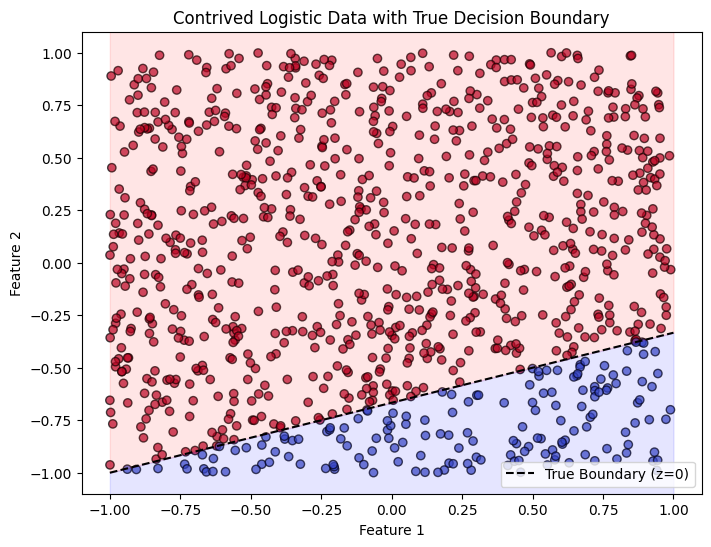

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")

# to draw the boundary
# z1 / z2 == 1 is where logits are equal, in this binary case z1 == 0 
# so multiply both sides and you get 0 == z2, the point x @ true_parameters = 0
# x is two dimensions, x1 and x2, so solve for x2 = -x1 * param1 /param_2 - 1/param2 * bias
# so new equation is m = -x1 * param1 /param_2, b = 1/param2 * bias
# pick two x1 points and plot their x2 and connect it to get the boundary

x_vals = np.array([-1, 1])
# true_parameters[0] is bias, [1] is x1, [2] is x2
m = -true_parameters[1] / true_parameters[2]
b = - true_parameters[0] / true_parameters[2]
y_vals = m * x_vals + b



plt.plot(x_vals, y_vals, '--', color='black', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Contrived Logistic Data with True Decision Boundary")
plt.legend()

So we see the linear decision boundary of this contrived example in the original space of the features.
Let's apply our two optimization strategies to see what we get.

In [3]:
def logistic_regression_solve_gradient_descent(params, learning_rate, data, labels, max_steps=100000):
    params = params.copy()
    gradient = [float("inf")]
    steps = 1
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        gradient = (1 / (1 + np.exp(-(data @ params))) - labels).T @ data
        params -= learning_rate*gradient.T
        steps += 1
    return params, steps
found_params, steps = logistic_regression_solve_gradient_descent(np.random.random((3,1)), 0.1, data, labels)

Found parameters[[189.86317613]
 [-95.64764987]
 [284.90706604]]
True parameters[[ 2]
 [-1]
 [ 3]]
Steps 100000
Accuracy: 1.0


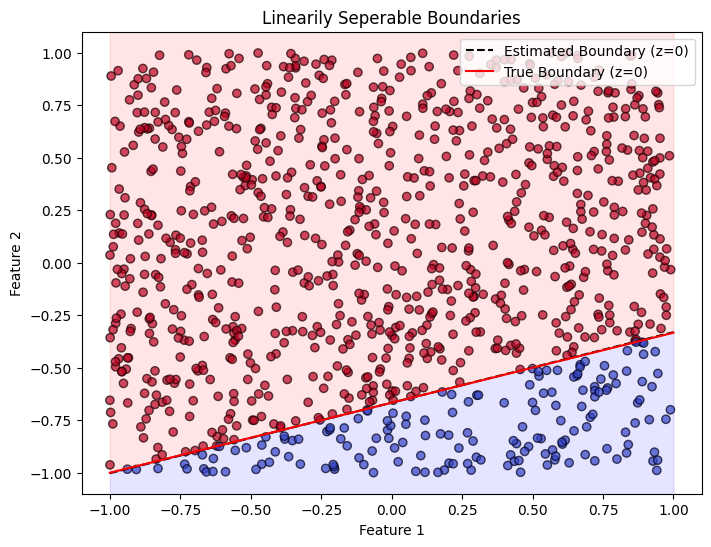

In [4]:
print(f"Found parameters{found_params}")
print(f"True parameters{true_parameters}")
print(f"Steps {steps}")
estimates = (1 / (1 + np.exp(-(data @ found_params))))
print(f"Accuracy: {((estimates > 0.5) == labels).mean()}")

m = -found_params[1] / found_params[2]
b = -found_params[0] / found_params[2]

x_vals = np.array([-1, 1])
y_vals_estimate = m * x_vals + b

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.plot(x_vals, y_vals_estimate, '--', color='black', label='Estimated Boundary (z=0)')
plt.plot(x_vals, y_vals, color='red', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals_estimate, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals_estimate, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearily Seperable Boundaries")
plt.legend()
plt.show()

As we can see, the estimated boundary closely matches the true underlying boundary after being trained via Gradient Descent. Even though the raw parameter magnitudes are different, their ratios remain constant. 

This results in an equivalent classification solution because the decision boundary is defined entirely by where the logit equals zero ($z = 0$). Algebraically, if you multiply both sides of an equation equaling zero by any positive scalar constant, the geometric line remains exactly the same. The model simply scaled up the parameters to make the logits larger (creating a steeper sigmoid curve) without changing the location of the boundary itself. Geometrically, the feature coefficients in the hyperplane equation $\vec{w}^T \vec{x} + b = 0$ act as the normal vector orthogonal to the plane; scaling them by a positive value changes their magnitude but preserves their exact direction and the boundary they define.

So the boundary is found but convergence based on gradient norm is not reached (we hit our max steps).
This happens because if the data is linearily seperable, the gradient continues freely to drive the probabilities to 1.0 without penalty of misclassifying other points, eventually getting to infinity.
Let's take a look at this:

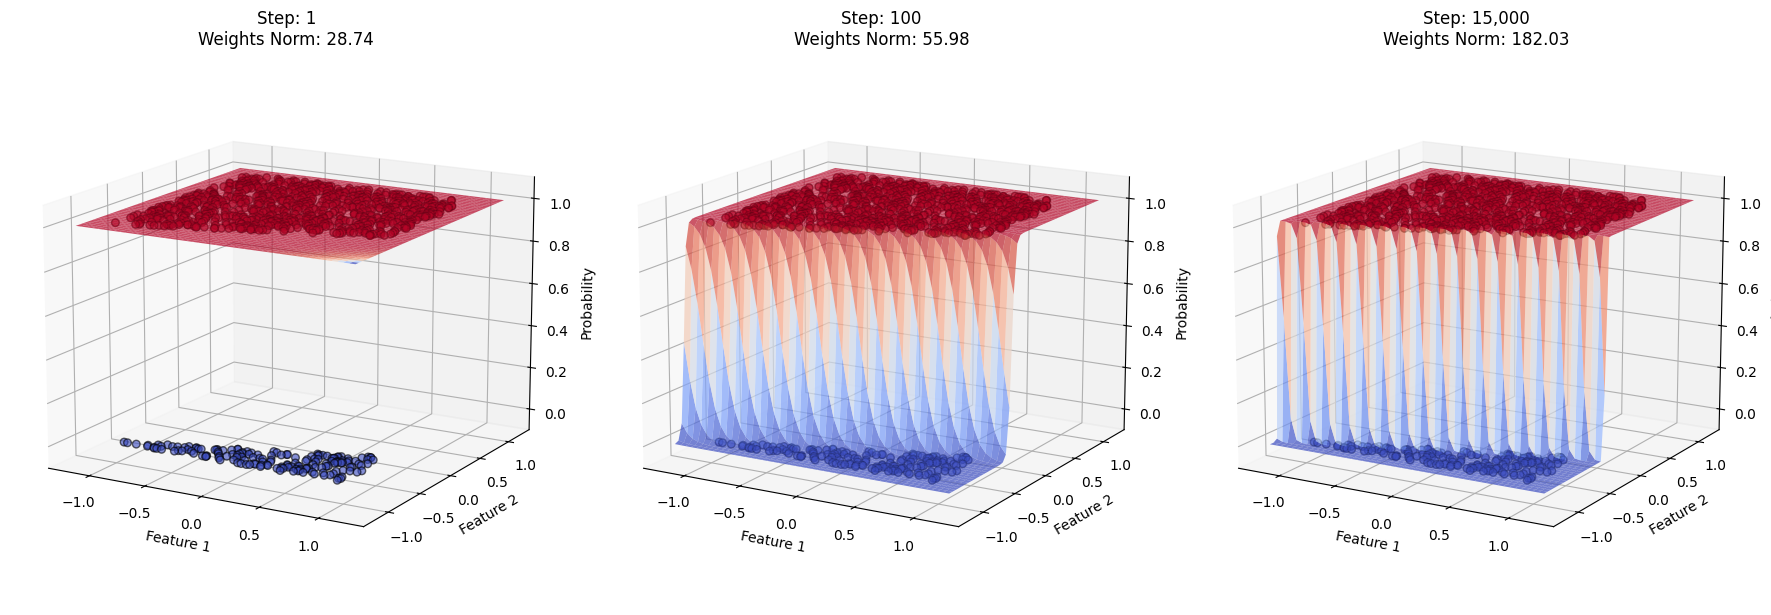

In [5]:
def logistic_regression_solve_gradient_descent_history(params, learning_rate, data, labels, max_steps=20000):
    params = params.copy()
    gradient = np.array([float("inf")])
    steps = 0
    
    # We will save the parameters at these specific iterations
    snapshots = [1, 100, 15000]
    history = []
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        if steps in snapshots:
            history.append((steps, params.copy()))
            
        predictions = 1 / (1 + np.exp(-(data @ params)))
        gradient = data.T @ (predictions - labels)
        params -= learning_rate * gradient
        steps += 1
        
    return params, history

initial_guess = np.random.random((3,1))
_, history = logistic_regression_solve_gradient_descent_history(initial_guess, 0.1, data, labels)

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 6))

x1_grid = np.linspace(-1.2, 1.2, 50)
x2_grid = np.linspace(-1.2, 1.2, 50)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

for i, (step, saved_params) in enumerate(history):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.scatter(data[:, 1], data[:, 2], labels.flatten(), 
               c=labels.flatten(), cmap='coolwarm', edgecolors='k', s=30, alpha=0.6)
    
    w0, w1, w2 = saved_params[0].item(), saved_params[1].item(), saved_params[2].item()
    Z_logits = w0 + w1*X1 + w2*X2
    Z_prob = 1 / (1 + np.exp(-Z_logits))
    
    ax.plot_surface(X1, X2, Z_prob, cmap='coolwarm', alpha=0.7, edgecolor='none')
    
    ax.set_title(f"Step: {step:,}\nWeights Norm: {np.linalg.norm(saved_params):.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Probability")
    ax.set_zlim(-0.1, 1.1)
    ax.view_init(elev=15, azim=-60) # Low elevation to clearly see the steepness

plt.tight_layout()
plt.show()

So the output probability surface keeps getting stretched to push the probability of the label 1 points closer and closer to 1, now lets do this analysis with linearily seperable data:

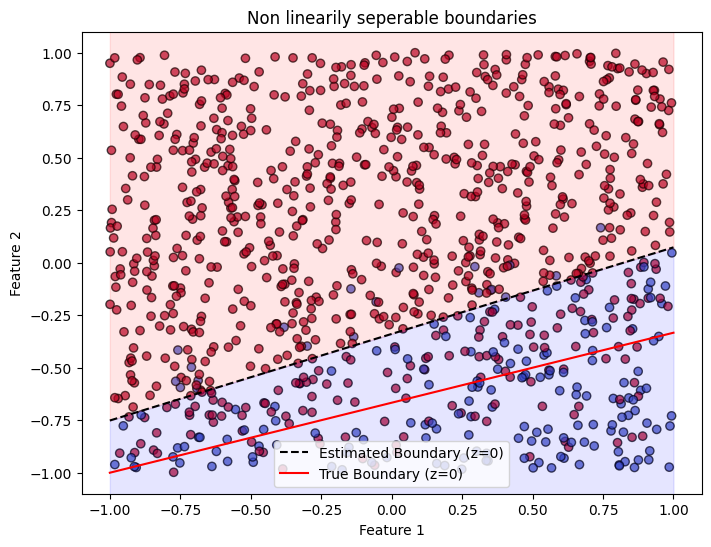

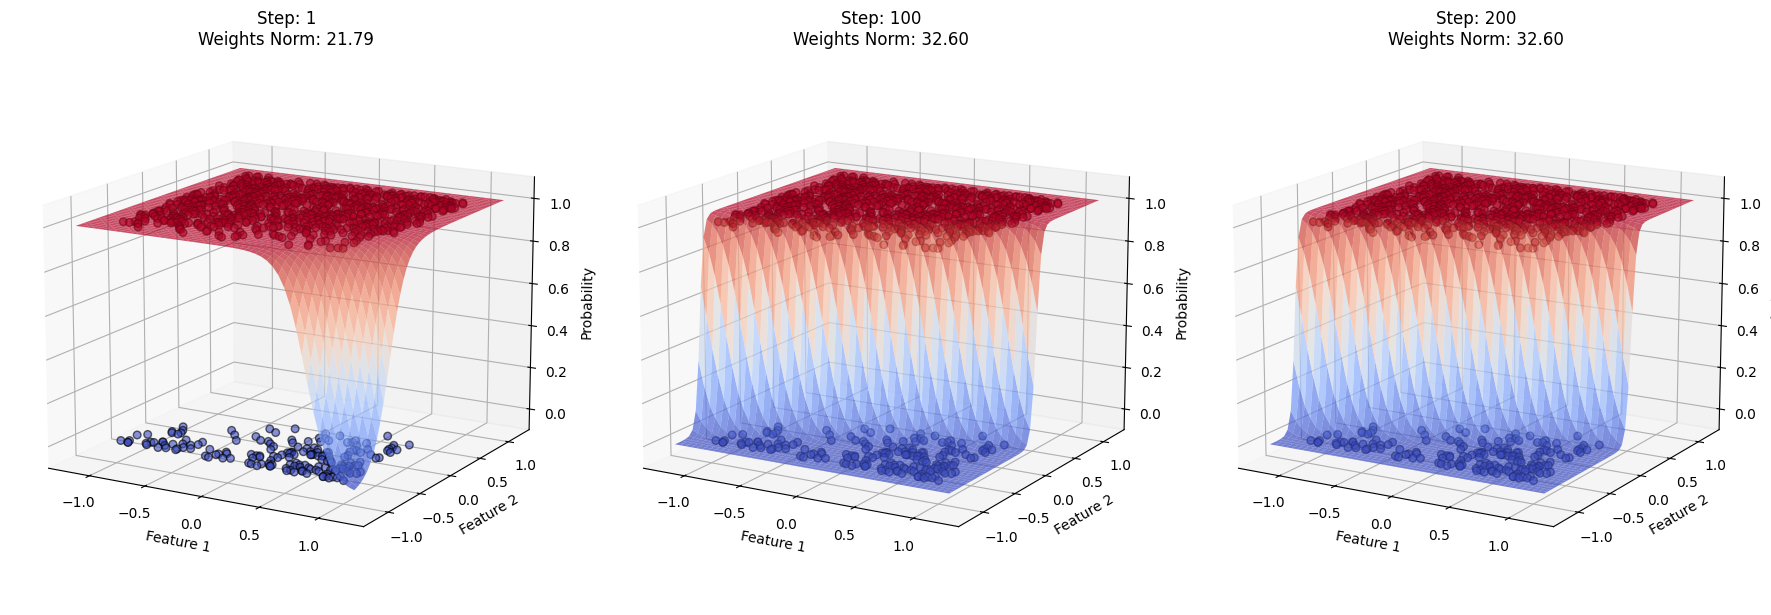

In [6]:
true_coefficients = np.array([-1, 3])
true_bias = np.array([2])

true_parameters = np.hstack([true_bias, true_coefficients]).reshape(-1, 1)

# let's get some data
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

x_vals = np.array([-1, 1])
m = -true_parameters[1] / true_parameters[2]
b = - true_parameters[0] / true_parameters[2]
y_vals = m * x_vals + b


def logistic_regression_solve_gradient_descent_history(params, learning_rate, data, labels, max_steps=20000):
    params = params.copy()
    gradient = np.array([float("inf")])
    steps = 0
    
    # We will save the parameters at these specific iterations
    snapshots = [1, 100, 200]
    history = []
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        if steps in snapshots:
            history.append((steps, params.copy()))
            
        predictions = 1 / (1 + np.exp(-(data @ params)))
        gradient = data.T @ (predictions - labels)
        params -= learning_rate * gradient
        steps += 1
        
    return params, history

initial_guess = np.random.random((3,1))
found_params, history = logistic_regression_solve_gradient_descent_history(initial_guess, 0.1, data, labels)

m = -found_params[1] / found_params[2]
b = -found_params[0] / found_params[2]

x_vals = np.array([-1, 1])
y_vals_estimate = m * x_vals + b

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.plot(x_vals, y_vals_estimate, '--', color='black', label='Estimated Boundary (z=0)')
plt.plot(x_vals, y_vals, color='red', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals_estimate, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals_estimate, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non linearily seperable boundaries")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 6))

x1_grid = np.linspace(-1.2, 1.2, 50)
x2_grid = np.linspace(-1.2, 1.2, 50)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

for i, (step, saved_params) in enumerate(history):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.scatter(data[:, 1], data[:, 2], labels.flatten(), 
               c=labels.flatten(), cmap='coolwarm', edgecolors='k', s=30, alpha=0.6)
    
    w0, w1, w2 = saved_params[0].item(), saved_params[1].item(), saved_params[2].item()
    Z_logits = w0 + w1*X1 + w2*X2
    Z_prob = 1 / (1 + np.exp(-Z_logits))
    
    ax.plot_surface(X1, X2, Z_prob, cmap='coolwarm', alpha=0.7, edgecolor='none')
    
    ax.set_title(f"Step: {step:,}\nWeights Norm: {np.linalg.norm(saved_params):.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Probability")
    ax.set_zlim(-0.1, 1.1)
    ax.view_init(elev=15, azim=-60) # Low elevation to clearly see the steepness

plt.tight_layout()
plt.show()

If the data is *not* linearly separable (i.e., you can see points crossing over the boundary deep into opposing territory), the competing errors create a natural mathematical balance. The optimizer finds a true minimum, allowing the gradient norm to successfully converge toward zero.

Because we cannot guarantee in advance whether a dataset will be perfectly separable or not, production-level Gradient Descent implementations always use dual stopping criteria: reaching a near-zero gradient norm OR hitting a maximum number of iterations. 

```python
def logistic_regression_solve_gradient_descent(params, learning_rate, data, labels, max_steps=100000):
    params = params.copy()
    gradient = np.array([np.inf]) # Use numpy infinity for consistency
    steps = 1
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        gradient = (1 / (1 + np.exp(-(data @ params))) - labels).T @ data
        params -= learning_rate * gradient.T
        steps += 1
        
    return params, steps

So now we develop the solver using Newton's Second Order Method. In this example (binary) the gradient is already a vector, and the hessian can is the derivative of this vector, now we could compute this at a point by point level by $H = \sum_{i=1}^{N} p_i*(1-p_i) x_i \cdot {x_i}^T$. A much faster way that iteration is to do the following matrix multiplication:
$X^T D X$ where D is $\text{Diagnol}(p(1-p))$ so every row of X is being scaled by diagnol element of P then multiplied by its transpose! We can also avoid creating a NxN diagnol matrix by simply broadcasting the $p(1-p)$ term on the right matrix.

In [7]:
def logistic_regression_solve_newtons(params, data, labels, max_steps=20):
    params = params.copy()
    update = np.array([np.inf])
    steps = 1
    while np.linalg.norm(update) > 0.0001 and steps < max_steps:
        predictions = (1 / (1 + np.exp(-(data @ params))))
        gradient = (predictions - labels).T @ data
        hessian = data.T @ (predictions * (1- predictions) * data)
        update = np.linalg.inv(hessian) @ gradient.T
        params -= update
        steps += 1
    return params, steps
newton_params, newton_steps = logistic_regression_solve_newtons(np.random.uniform(-1, 1, (3,1)), data, labels)
newton_params, newton_steps

(array([[ 3.26134028],
        [-1.80580583],
        [ 4.78678326]]),
 8)

In [8]:
# get accuracy
predictions = (1 / (1 + np.exp(-data @ newton_params)))
((predictions > 0.5).astype(int) == labels).mean()

np.float64(0.886)

It is important to note how the variance $p(1-p)$ dictates the optimizer's behavior. The Hessian matrix weights each data point by its variance. Points the model is unsure about ($p \approx 0.5$) have the maximum variance, so they heavily influence the Hessian, creating sharp curvature. Points the model is highly confident about ($p \approx 1$ or $0$) have near-zero variance and are practically ignored. 

However, because Newton's Method updates the parameters using the **inverse** of the Hessian ($H^{-1}$), this creates a brilliant dynamic: 
* Where the model is **unsure** (large Hessian), the inverse creates a **small, careful** update step to avoid overshooting the boundary.
* Where the model is **highly confident** (small Hessian), the inverse creates a **massive, aggressive** leap forward.

We will now visualize the loss function and paths these two approaches take.

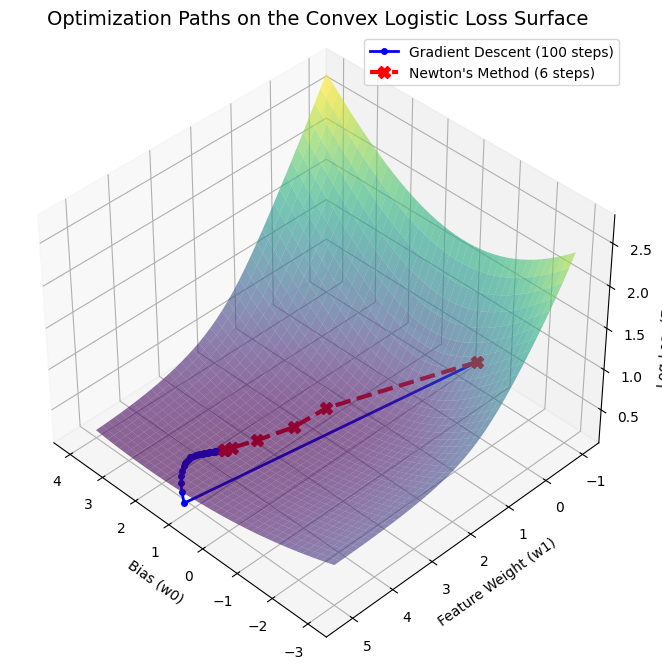

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
num_samples = 150

x_1d = np.random.uniform(-3, 3, (num_samples, 1))
data_2d = np.hstack([np.ones((num_samples, 1)), x_1d])

true_w = np.array([[1.0], [2.0]])
logits_2d = data_2d @ true_w + np.random.normal(0, 1.5, (num_samples, 1))
labels_2d = (logits_2d > 0).astype(int)


def compute_log_loss(w0, w1):
    w = np.array([[w0], [w1]])
    # Stable logit clipping to prevent overflow
    logits = np.clip(data_2d @ w, -250, 250) 
    preds = 1 / (1 + np.exp(-logits))
    preds = np.clip(preds, 1e-15, 1 - 1e-15) 
    return -np.mean(labels_2d * np.log(preds) + (1 - labels_2d) * np.log(1 - preds))

w0_grid = np.linspace(-3, 4, 40)
w1_grid = np.linspace(-1, 5, 40)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
Loss_Surface = np.zeros_like(W0)

for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Loss_Surface[i, j] = compute_log_loss(W0[i, j], W1[i, j])

initial_guess = np.array([[-1.5], [-0.0]]) 

w_gd = initial_guess.copy()
path_gd = [w_gd.flatten()]
for _ in range(100): 
    logits = np.clip(data_2d @ w_gd, -250, 250)
    preds = 1 / (1 + np.exp(-logits))
    grad = data_2d.T @ (preds - labels_2d) 
    w_gd -= 0.05 * grad 
    path_gd.append(w_gd.flatten())
path_gd = np.array(path_gd)


w_nt = initial_guess.copy()
path_nt = [w_nt.flatten()]
for _ in range(6): 
    logits = np.clip(data_2d @ w_nt, -250, 250)
    preds = 1 / (1 + np.exp(-logits))
    grad = data_2d.T @ (preds - labels_2d)
    
    H = data_2d.T @ (preds * (1 - preds) * data_2d)
    H += np.eye(H.shape[0]) * 1e-4 
    
    w_nt -= np.linalg.inv(H) @ grad
    path_nt.append(w_nt.flatten())
path_nt = np.array(path_nt)

z_gd = [compute_log_loss(w[0], w[1]) for w in path_gd]
z_nt = [compute_log_loss(w[0], w[1]) for w in path_nt]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W0, W1, Loss_Surface, cmap='viridis', alpha=0.6, edgecolor='none')

ax.plot(path_gd[:, 0], path_gd[:, 1], z_gd, 
        color='blue', marker='o', markersize=4, linewidth=2, label=f'Gradient Descent ({len(path_gd)-1} steps)')

ax.plot(path_nt[:, 0], path_nt[:, 1], z_nt, 
        color='red', marker='X', markersize=8, linewidth=3, linestyle='--', label=f"Newton's Method ({len(path_nt)-1} steps)")

ax.set_title("Optimization Paths on the Convex Logistic Loss Surface", fontsize=14)
ax.set_xlabel("Bias (w0)")
ax.set_ylabel("Feature Weight (w1)")
ax.set_zlabel("Log-Loss (Error)")
ax.legend()
ax.view_init(elev=40, azim=135) 

plt.show()

As visualized, Newton's Method takes a much more direct and step-efficient path to the global minimum. However, this mathematical efficiency comes at a massive computational cost. 

It requires calculating and inverting the $P \times P$ Hessian matrix at every step, which carries an $O(P^2)$ space complexity and an $O(P^3)$ time complexity. While this is trivial for classical statistics with a few variables, it becomes strictly prohibitive in highly parameterized machine learning models. Furthermore, unlike first-order gradients, matrix inversion is non-trivial to compute in a distributed, multi-node environment. For large-scale problems, Gradient Descent (and its stochastic variants) remains the undisputed standard.

# Two Goals
Next, we will explore the dual objectives of Logistic Regression. In practice, modelers face an inherent tension between Interpretability—isolating and understanding the exact impact of individual features—and Predictive Power—tuning the model to minimize generalization error on new data.

## Interpertability
When our primary goal is interpretability, we want to rigorously understand the relationship between the features and the target label. Specifically, we want to quantify exactly how a one-unit change in a given feature impacts the probability of a positive classification.

The following are the assumptions and how we test and mitigate violations of them (these are assumptions listed in the beginning of this notebook).

### Independence of Observations
Fundamentally, this assumption dictates that every single row in your dataset must be a completely independent entity, with absolutely no relation to any other row. Mathematically, this means that knowing the features or the outcome of Row $A$ gives you zero predictive power about what Row $B$ will look like. 

Every row must represent a discrete, separate event. If you flip a coin twice, the second flip is completely independent. But if you measure a patient's blood pressure on Tuesday, and measure that *same* patient again on Wednesday, those two rows are related. They share an underlying, unmeasured baseline (that specific patient's genetics, diet, and lifestyle). Row 2 is essentially just Row 1 plus a little bit of daily noise. They aren't two separate entities; they are one entity stretched across two rows.

The reason this matters for interpretability is that when we optimize the Negative Log-Likelihood (NLL), the standard error of our coefficients is inversely related to the curvature (steepness) of the NLL "bowl" at its minimum (we will examine this shortly after this assumptions section). The algorithm calculates the overall likelihood by multiplying the probabilities of individual rows, which is mathematically valid only if those events are truly independent. If they are not (e.g., clustered data), the algorithm is multiplying redundant information. This creates a fake NLL curve that is artificially steep. While the bottom of the bowl (the β coefficients) remains in the correct location, the artificial steepness tricks the model into calculating a much smaller Standard Error, destroying the reliability of the p-values.

##### How it is Violated (The 3 Main Culprits)
1. **Repeated Measures:** Measuring the same subject multiple times (e.g., tracking the same patient's heart rate once a month for a year).
2. **Clustered / Hierarchical Data:** Data grouped by a shared environment (e.g., testing students who all share the same teacher, or houses located in the same neighborhood).
3. **Temporal Autocorrelation:** Time-series data where today's value is heavily dependent on yesterday's value (e.g., predicting daily stock market movements).

##### How to Detect It
Unlike other assumptions, independence is primarily checked through **study design and logic** rather than pure math. You must ask: *"How was this data collected?"*
* **Logical Check:** Does a single entity (person, machine, location) appear in multiple rows? 
* **Statistical Check (Time-Series):** You can plot an Autocorrelation Function (ACF) to see if residuals are correlated with past versions of themselves. This is where you test different time shifts (lags) in the residuals, calculate the correlation between the original and the shifted residuals, and plot that correlation against the shift size. In an independent dataset, this plot should look like pure, random white noise. If clear spikes appear at certain lags, it proves the presence of temporal dependencies.
* **Statistical Check (Clusters):** Visualizing Grouped Residuals: This is the single most robust way to detect clustering. By grouping the model's errors (residuals) by the cluster ID, you can see if a cluster is systematically dragging the outcome up or down. This catches all cluster effects, regardless of where they hide.

##### How to Mitigate Violations
If your data is not independent, standard Logistic Regression will yield untrustworthy inference. You must adjust your approach:
1. **Aggregation (The Data Science Fix):** Group the data by the repeating entity. If you have 10 rows for one patient, aggregate them into a single row representing that patient's *average* or *maximum* values. (Trades dataset size for perfect independence).
2. **Cluster-Robust Standard Errors (The Sandwich Estimator):**
You can tell the statistical software to group the standard error calculations by a specific cluster (e.g., `cov_type='cluster'`). This doesn't change the $\hat{\theta}$ coefficients, but it recalculates honest, wider Standard Errors to fix the p-values. It does this by directly factoring the covariance between correlated observations back into the variance calculation using the Huber-White Sandwich Estimator. 

    **The Math:** We will dig in more detail into this as we implement interpertability, but using a first-order Taylor expansion of the gradients, the variance of our coefficients is defined as the "Sandwich": $V[\hat{\theta}] = H^{-1} \cdot V[g] \cdot H^{-1}$. 
    * **If observations are independent:** We can take advantage of the *Information Matrix Equality*, which proves that the variance of the gradients equals the curvature ($V[g] = H$). The matrices cancel out, and the formula beautifully simplifies to the naive variance: $V[\hat{\theta}] = H^{-1}$. 
    * **If observations are clustered:** The Information Matrix Equality breaks ($V[g] \neq H$). Because they are no longer equal, the math does not cancel out. The software must explicitly estimate both the inverse curvature ($H^{-1}$) and the true variance of the grouped gradients ($V[g]$), and manually compute the full equation: $H^{-1} \cdot V[g] \cdot H^{-1}$. To estimate the hessian, you would get second derivative of every point of NLL and add it together (will show later), to estimate the $V[g]$, we take advantage of $E[g] == 0$ but because they're not independent ($V[X + Y] = V[X] + V[Y] + COV[X,Y]$), instead of squaring each row's gradient individually, we sum the gradients within each cluster first, and then square those combined cluster-level gradients then sum across the clusters. This mathematically bakes the hidden covariance right into the variance matrix.
3. **Time Lagged variables:** If you detect ACF, the easiest and most interpretable machine-learning fix is almost always add lagged variables. It directly models the time dynamic rather than just widening the standard errors to hide from it.

4. **Longitudinal Data (Time + Clusters):**
If your data violates both time and cluster independence (e.g., tracking the same patients over multiple days), standard Logistic Regression fails completely. You must upgrade to longitudinal models. 
    * **Generalized Estimating Equations (GEE):** Acts like an advanced Sandwich Estimator. It allows you to specify the exact time-series structure (like AR-1) *inside* your clusters. **Interpretability:** Yields "Population-Average" insights (How a feature affects the overall average population).
    * **Generalized Linear Mixed Models (GLMM):** Also known as Mixed-Effects models. It calculates a unique baseline intercept for every single cluster (Random Effects) alongside the standard feature coefficients (Fixed Effects). **Interpretability:** Yields "Subject-Specific" insights (How a feature affects a specific individual, controlling for their unique genetic/environmental baseline).
> **Note on Scope:** While GEE and GLMM are the mathematically correct solutions for longitudinal data, they represent an entirely different class of advanced econometrics. Because the core focus of this notebook is standard Logistic Regression, we will not be implementing these mixed models here.

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Setup the Illusion: 100 Patients, 10 observations each
n_patients = 100
obs_per_patient = 10
total_N = n_patients * obs_per_patient  # 1000 total rows

np.random.seed(42)

# 2. Engineer the Patient Bias (The hidden cluster effect)
# We assign a strong, hidden log-odds modifier to each specific patient
patient_biases = np.random.normal(loc=0, scale=2.5, size=n_patients)

# 3. Build the dataset
data_clustered = []
patient_ids = []

for patient_id in range(n_patients):
    # Get this specific patient's secret bias
    specific_bias = patient_biases[patient_id]
    
    for _ in range(obs_per_patient):
        # Generate random features for this specific visit
        feat_1 = np.random.normal(0, 1)
        feat_2 = np.random.normal(0, 1)
        
        # LOGIT EQUATION: (True Beta * Feature) + PATIENT BIAS + random noise
        # Notice we make the true beta for feat_2 very weak (0.2)
        logit = (1.5 * feat_1) + (0.2 * feat_2) + specific_bias + np.random.normal(0, 0.5)
        
        # Convert to probability and binary label
        prob = np.exp(logit) / (1 + np.exp(logit))
        label = 1 if prob > 0.5 else 0
        
        data_clustered.append([1.0, feat_1, feat_2, label]) # 1.0 is the Bias/Intercept column
        patient_ids.append(patient_id)

# Convert to DataFrames for statsmodels
df_clustered = pd.DataFrame(data_clustered, columns=['Bias', 'Feature_1', 'Feature_2', 'Label'])
labels_clustered = df_clustered.pop('Label')

In [11]:
print("--- MODEL 1: THE NAIVE MODEL (Assumes 1000 Independent Rows) ---")
naive_model = sm.Logit(labels_clustered, df_clustered).fit(disp=False)
print(naive_model.summary().tables[1])

print("\n--- MODEL 2: THE HONEST MODEL (Corrects for 100 Clusters) ---")
honest_model = sm.Logit(labels_clustered, df_clustered).fit(
    disp=False, 
    cov_type='cluster', 
    cov_kwds={'groups': patient_ids}
)
print(honest_model.summary().tables[1])

--- MODEL 1: THE NAIVE MODEL (Assumes 1000 Independent Rows) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Bias          -0.0619      0.072     -0.862      0.389      -0.203       0.079
Feature_1      1.1619      0.089     13.075      0.000       0.988       1.336
Feature_2      0.1636      0.074      2.212      0.027       0.019       0.309

--- MODEL 2: THE HONEST MODEL (Corrects for 100 Clusters) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Bias          -0.0619      0.176     -0.351      0.726      -0.408       0.284
Feature_1      1.1619      0.130      8.964      0.000       0.908       1.416
Feature_2      0.1636      0.079      2.073      0.038       0.009       0.318


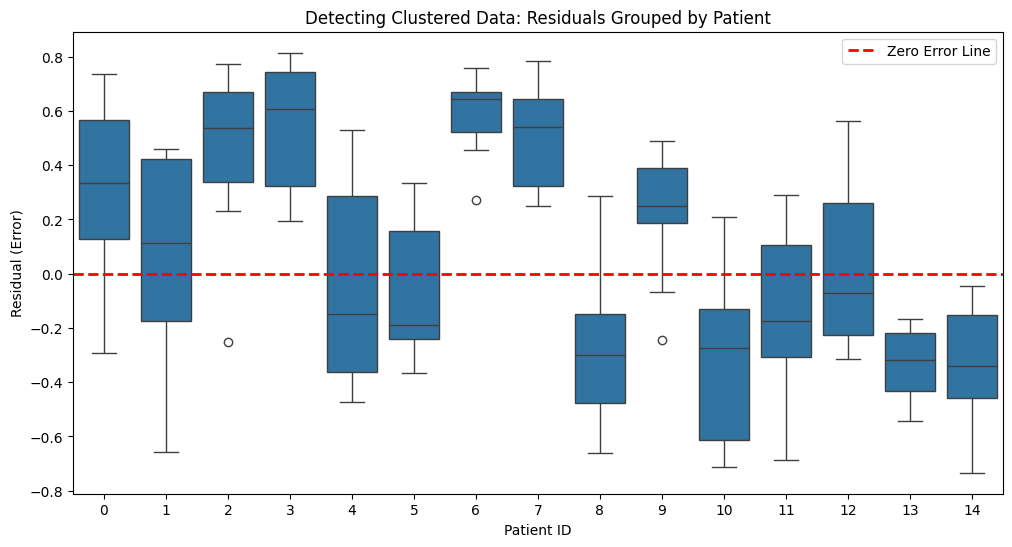

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the predictions from our Naive Model
predictions = naive_model.predict(df_clustered)

# 2. Calculate the Residuals (Actual Label - Predicted Probability)
residuals = labels_clustered - predictions

# 3. Create a DataFrame for plotting
df_residuals = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Residual': residuals
})

# 4. Plot the residuals for just the first 15 patients to see the pattern
plt.figure(figsize=(12, 6))
sns.boxplot(x='Patient_ID', y='Residual', data=df_residuals[df_residuals['Patient_ID'] < 15])
plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Zero Error Line")
plt.title("Detecting Clustered Data: Residuals Grouped by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Residual (Error)")
plt.legend()
plt.show()

### Absence of Multicollinearity
We must first ensure our features are not highly correlated with one another. If our features overlap too much, it creates multicollinearity. This confuses the model, causing standard errors to explode and corrupting any p-value-based inference tests we try to run later.

We test for this using the Variance Inflation Factor (VIF). The variance inflation factor looks at how well a feature can be predicted from other features via a ratio of the error in prediction. Specifically, it compares the error if you predicted that feature's average (SST, or total sum of squares) versus if you fit a model using the other features to predict it (SSR, or sum of squared residuals). 

If a VIF is 1, for example, it shows that using the other features is no better than the simple average prediction. But this ratio's size corresponds to how redundant the feature is given the other features. A common rule of thumb is that VIF > 5 indicates problematic multicollinearity, and VIF > 10 indicates severe multicollinearity. This view is mathematically equivalent to $\text{VIF} = 1 / (1 - R^2)$, because $1 - R^2$ is exactly the ratio of $SSR / SST$.

To calculate VIF for categorical variables, they must first be converted into binary dummy variables (0 and 1). We can then use the standard squared-error VIF approach. However, to avoid perfect multicollinearity (a VIF of infinity), we must always drop one reference category (known as avoiding the Dummy Variable Trap).

So we can use VIF as a filter (say above 5, drop iteratively) as a feature selection method for interpretation.


In [13]:
# we will add a third feature thats a linear trasnformation of the second and some noise and get the VIFs to show this.
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data_redundant = np.concat([data,  (data[:, 2] * 6 + np.random.uniform(-0.1, 0.1, (data.shape[0]))).reshape(-1, 1)],axis=1)
def check_multicollinearity(data, feature_names):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = feature_names
    vif_data["VIF Score"] = [
        variance_inflation_factor(data, i)
        for i in range(data.shape[1])
    ]
    return vif_data
check_multicollinearity(data_redundant, ["bias", "feature_1", "feature_2", "feature_3"])

,Feature,VIF Score
0,bias,1.004668
1,feature_1,1.000940
2,feature_2,3538.249867
3,feature_3,3538.214843


In [14]:
# now lets just get the first 3 features:
check_multicollinearity(data, ["bias", "feature_1", "feature_2"])


,Feature,VIF Score
0,bias,1.002342
1,feature_1,1.000841
2,feature_2,1.000841


As we can see the VIF is reduced once we take out one of the redundant features.


#### Linearity in the Logit
The continuous features must have a linear relationship with the log-odds of the target variable.

This can be tested with visual inspection, plotting each logit with regards to it's log-odds, practically we bin each feature and then compute an average clipped log odds for each group. Then plot these this should roughly be a line. While visual inspection of binned log-odds scales efficiently for large datasets, it requires a sufficient sample size to yield stable probabilities. A standard rule of thumb is to use 10 to 20 bins, ensuring at least 30-50 observations per bin to avoid extreme probability spikes.

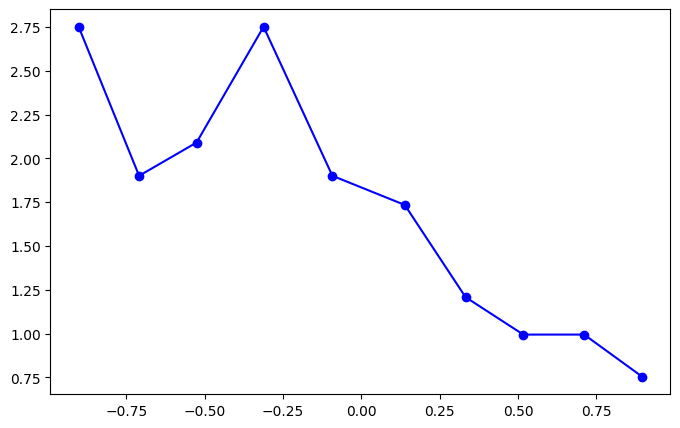

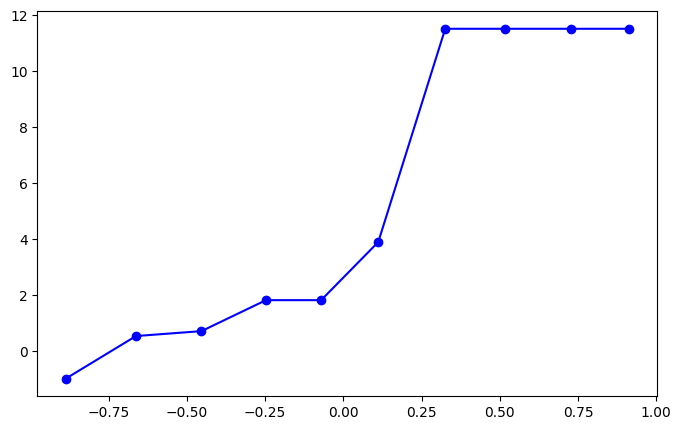

In [15]:
import pandas as pd
# plotting binned class logit versus their labels average clipped logit 
def plot_binned_log_odds_with_label(feature_values, labels, num_bins=10):
    # bin
    data = pd.DataFrame({'x': feature_values.flatten(), 'y': labels.flatten()})
    data["bin"] = pd.qcut(data["x"], q=num_bins)
    grouped = data.groupby('bin', observed=False).agg({'x': 'mean', 'y': 'mean'})
    p = np.clip(grouped["y"], 1e-5, 1 - 1e-5)
    grouped["log_odds"] = np.log(p/(1-p))
    plt.figure(figsize=(8,5))
    plt.plot(grouped["x"], grouped["log_odds"], marker='o', linestyle='-', color='b')
    plt.show()

plot_binned_log_odds_with_label(data[:, 1], labels)

plot_binned_log_odds_with_label(data[:, 2], labels)

As you can see its roughly linear, the max at 12 is clipping.

Another way to test is to use Box-Tidwell test, which adds $Xln(X)$ for each feature as a detector one feature at a time and keeping all the base features (mathematically detects higher power terms when optimized), and look at the p-value for it with the null hypothesis test being it's coefficient is 0. It is crucial to note that the Box-Tidwell test is highly sensitive to multicollinearity. If the original features are highly correlated, their $X \ln(X)$ interaction terms will also be correlated. We must verify the **Absence of Multicollinearity** before we can fully trust our inference tests including the Box-Tildwell, otherwise the multi-colinearity will render our analysis ineffective.

**Note on the Natural Logarithm:** We must be careful when calculating the $X \ln(X)$ interaction terms, as the natural logarithm is mathematically undefined for zero and negative numbers. To safely bypass this, we shift the feature values up by adding a constant to ensure all values are strictly positive. This linear shift is safe to do because Logistic Regression models include a bias (intercept) term, which seamlessly absorbs the constant without altering the feature's coefficient or the underlying geometric shape of the data.

In [16]:
import statsmodels.api as sm

def box_tidwell_test(data, labels):
    base_features = {'Bias': data[:, 0]}
    for j in range(1, data.shape[1]):
        base_features[f'Feature_{j}'] = data[:, j]
        
    for i in range(1, data.shape[1]):
        shifted = data[:, i] - np.min(data[:, i]) + 1
        interaction = shifted * np.log(shifted)
        
        # 3. Copy the base features and add ONLY the current interaction term
        test_features = base_features.copy()
        test_features[f'Interaction_{i}'] = interaction
        
        # 4. Fit the model
        df_bt = pd.DataFrame(test_features)
        bt_model = sm.Logit(labels, df_bt).fit(disp=False)
        
        print(f"\n--- Box-Tidwell Test for Feature {i} ---")
        print(bt_model.summary().tables[1])

# Run it!
box_tidwell_test(data, labels)


--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              5.2790      2.317      2.279      0.023       0.739       9.820
Feature_1         0.4940      2.624      0.188      0.851      -4.650       5.638
Feature_2         4.8003      0.386     12.431      0.000       4.043       5.557
Interaction_1    -1.3671      1.558     -0.878      0.380      -4.420       1.686

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              0.5915      3.897      0.152      0.879      -7.046       8.229
Feature_1        -1.7887      0.222     -8.075      0.000      -2.223      -1.355
Feature_2         1.9388      4.158      0.466      0.641      -6.211      10.088
Interaction_2     

##### What to do if the Linearity Assumption is Violated
If the tests indicate a significant non-linear relationship (p-value < 0.05), we cannot use the raw continuous feature directly, as it will distort our model's coefficients and ruin interpretability. We can mitigate this using one of three methods:

1. **Transformations:** Apply a non-linear function (e.g., $\log(X)$ or $\sqrt{X}$) to the feature to linearize the relationship.
2. **Polynomial Expansion:** Add higher-order terms (like $X^2$) to the dataset, allowing the model to fit a curve. 
3. **Discretization (Binning):** Convert the continuous feature into categorical bins (e.g., converting continuous "Age" into "Age Brackets"). This removes the linearity requirement entirely by treating different ranges of the feature as independent categories. Note on Discretization: Converting a continuous feature into categorical bins (dummy variables) completely bypasses the linearity assumption. Because each bin receives its own independent coefficient, the model can natively fit non-linear patterns (like U-shapes or sudden spikes) without requiring complex mathematical transformations. However, this comes at the cost of information loss, as all variation within a single bin is smoothed over.

If you transform or polynomial expansion you can run Box-Tidwell again for p-values.



--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              0.4471      6.415      0.070      0.944     -12.127      13.021
Feature_1        -6.6060      8.132     -0.812      0.417     -22.544       9.332
Feature_2         0.1211      0.383      0.316      0.752      -0.630       0.872
Interaction_1     2.7003      4.501      0.600      0.549      -6.122      11.523

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias            -28.5784     10.518     -2.717      0.007     -49.192      -7.964
Feature_1        -1.8536      0.519     -3.569      0.000      -2.872      -0.836
Feature_2       -38.8883     12.761     -3.047      0.002     -63.899     -13.877
Interaction_2    2

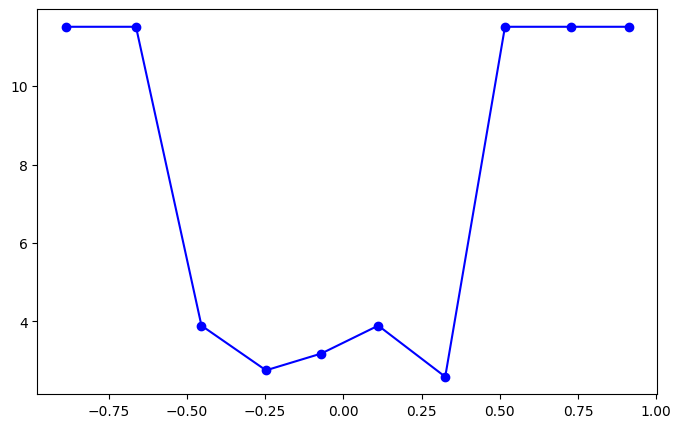

In [17]:
# let's see about adding a sqaured term.
squared = data[:, -1]**2
data_squared = np.hstack([data[:, :-1], squared.reshape(-1, 1)])
logits_squared = data_squared @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels_squared = (np.exp(logits_squared) / (1 + np.exp(logits_squared)) > 0.5).astype(int)
box_tidwell_test(data, labels_squared)

plot_binned_log_odds_with_label(data[:, 2], labels_squared)


As you can see we have a quadratic like structure which is what we expected, and the interaction has a p-value of 0.009, meaning that we detected that the log-odds are not linear in regards to feature 2.
Let's add the squared term back in and re run our tests.


--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              0.3767      6.351      0.059      0.953     -12.072      12.825
Feature_1        -5.5668      8.032     -0.693      0.488     -21.310      10.176
Feature_2         5.8286      1.873      3.112      0.002       2.158       9.499
Interaction_1     2.0735      4.452      0.466      0.641      -6.652      10.799

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              4.4060      0.570      7.724      0.000       3.288       5.524
Feature_1        -1.9035      0.525     -3.624      0.000      -2.933      -0.874
Feature_2      -327.7222    135.616     -2.417      0.016    -593.525     -61.920
Interaction_2   29

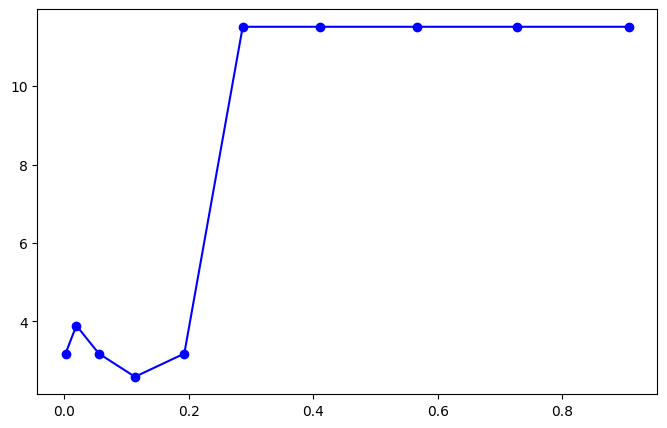

In [18]:
box_tidwell_test(data_squared, labels_squared)

plot_binned_log_odds_with_label(data_squared[:, 2], labels_squared)

As can be seen adding the square back in as the data gives us a more linear plot up to the expected saturation and box-tidwell tests indicate that the log odds are linear with respect to the features (which was a squared version of the original feature).

### No Influential Points
Negative Log Likelihood is sensitive to outliers, if a single point is very confidently wrong the penalty is -$ln(\text{small number})$, which approaches infinity, causing the coefficients to be modified drastically for a single point.
We can detect it by using using **Cook's Distance**, which estimates how wildly the coefficients would change if that specific point was removed. 

Cook's distance is a shortcut to refitting a model $N$ times and seeing how coefficients change.

**The Physics of the Pull (Newton's Method):** Under the hood, Cook's Distance calculates this shift using the physics of **Newton's Second-Order Optimization**. It calculates the distance the $\theta$ coefficients would move by applying Newton's Second Order Method's parameter update step to just the point:

$\theta_{t+1} - \theta_t = -H^{-1} \cdot g$

It's an approximation because the actual Hessian would change without that data point. 


Then a weighted norm (in whitened space) is gotten:

$D_i = \frac{1}{p} (\Delta \theta)^T \cdot \text{Var}(\hat{\theta})^{-1} \cdot (\Delta \theta)$ 

By dividing the shift by the Variance matrix, it standardizes the movement. It severely penalizes outliers that manage to move highly stable, confident coefficients, while forgiving outliers that only shift noisy, uncertain coefficients.


#### The Remedy (Handle with Care)
While the instinct is to simply drop influential points, blindly deleting data to make your model fit better is a statistical sin. When Cook's Distance flags a "black hole," you must investigate *why* it is there before acting:

1. **Is it a Typo? (Data Entry Error):** Someone's age is entered as 450 instead of 45. **Remedy:** Fix it or Drop it.
2. **Is it an Alien? (Different Population):** You are modeling middle-class incomes, and a billionaire is in your dataset. They belong to a fundamentally different data-generating process. **Remedy:** Drop it (and narrow your model's stated scope).
3. **Is it Extreme Reality? (Valid but Heavy):** The point is real; it just has a massive feature value that is dragging the curve. **Remedy:** DO NOT drop it. Apply a mathematical transformation (like taking the `log(x)`) to physically pull the extreme value back toward the center of the universe, or cap the extreme tails.


#### Process
1. Run model, get cook's distance.
2. Investigate points > 4 / N (heuristic), can we drop? Else no influential points.
3. Drop / transform feature, go to 1.

In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Generate the Normal Data (20 Students)
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 20)
# Pass if hours > 5, with a little bit of noise
pass_exam = np.where(hours_studied + np.random.normal(0, 1, 20) > 5, 1, 0)

# 2. Inject "The Alien" (Studied 15 hours, but Failed)
hours_studied = np.append(hours_studied, 15)
pass_exam = np.append(pass_exam, 0)

# Create DataFrame and add intercept
df = pd.DataFrame({'Hours': hours_studied, 'Passed': pass_exam})
df = sm.add_constant(df)

# ==========================================
# MODEL 1: BEFORE (The Black Hole Included)
# ==========================================
glm_before = sm.GLM(df['Passed'], df[['const', 'Hours']], family=sm.families.Binomial()).fit()
cooks_d_before = glm_before.get_influence().cooks_distance[0]
threshold = 4 / len(df)

print("--- BEFORE DROPPING ---")
print(f"Hours Coefficient: {glm_before.params['Hours']:.4f}")
print(f"Max Cook's D: {max(cooks_d_before):.4f} (Threshold: {threshold:.4f})")

# Find the exact row violating the threshold
outlier_index = np.where(cooks_d_before > threshold)[0]
print(f"Row {outlier_index} is pulling the model into a black hole!\n")

# ==========================================
# MODEL 2: AFTER (The Remedy)
# ==========================================
# Drop the specific outlier row identified by Cook's Distance
df_clean = df.drop(index=outlier_index)

glm_after = sm.GLM(df_clean['Passed'], df_clean[['const', 'Hours']], family=sm.families.Binomial()).fit()
cooks_d_after = glm_after.get_influence().cooks_distance[0]
new_threshold = 4 / len(df_clean)

print("--- AFTER DROPPING ---")
print(f"Hours Coefficient: {glm_after.params['Hours']:.4f}")
print(f"Max Cook's D: {max(cooks_d_after):.4f} (Threshold: {new_threshold:.4f})")

--- BEFORE DROPPING ---
Hours Coefficient: 0.4204
Max Cook's D: 2.2018 (Threshold: 0.1905)
Row [20] is pulling the model into a black hole!

--- AFTER DROPPING ---
Hours Coefficient: 1.4465
Max Cook's D: 0.6021 (Threshold: 0.2000)


### Interpreting the Results
Now that we've established the required assumptions for the model's interpretability, we can transition to statistical inference. We will look at how to calculate standard errors to build coefficient confidence intervals, derive $p$-values for hypothesis testing, and generate confidence intervals for our final predictions.

#### Standard Errors and Fisher Information
Unlike standard Linear Regression, Logistic Regression does not have a closed-form algebraic solution. Because we must find the coefficients using an iterative optimization algorithm, we cannot simply take the variance of a straightforward equation. Instead, we must derive the standard errors using the curvature of the optimization landscape (the Hessian) via the **Information Matrix Equality**.

**1. The Expected Score is Zero**
We start with the fundamental law of probability—the area under the curve is $1$:
$$\int f(x|\theta) dx = 1$$

If we take the derivative with respect to our parameters $\theta$, the constant becomes $0$:
$$\int \frac{\partial f}{\partial \theta} dx = 0$$

We then apply the **Log-Derivative Trick** ($\frac{\partial f}{\partial \theta} = f \cdot \frac{\partial \ln f}{\partial \theta}$):
$$\int f(x|\theta) \cdot \frac{\partial \ln f(x|\theta)}{\partial \theta} dx = 0$$

Because the integral of a PDF multiplied by a function is the Expected Value, we prove that the Expected Value of the Gradient (or "Score", $g$) is exactly zero:
$$E[g] = 0$$

**2. The Information Matrix Equality**
To find the variance, we take the second derivative of that same equation using the **Product Rule**:
$$\int \left[ f \cdot \frac{\partial^2 \ln f}{\partial \theta^2} + \frac{\partial f}{\partial \theta} \cdot \frac{\partial \ln f}{\partial \theta} \right] dx = 0$$

Applying the Log-Derivative trick a second time to the right-hand term:
$$\int \left[ f \cdot \frac{\partial^2 \ln f}{\partial \theta^2} + f \cdot \left(\frac{\partial \ln f}{\partial \theta}\right)^2 \right] dx = 0$$

We factor out the PDF $f(x|\theta)$ to convert the integrals back into Expected Values:
$$E\left[ \frac{\partial^2 \ln f}{\partial \theta^2} \right] + E\left[ \left(\frac{\partial \ln f}{\partial \theta}\right)^2 \right] = 0$$

Substituting our notation for the Hessian ($H$) and the Gradient ($g$):
$$E[H] + E[g^2] = 0 \implies E[g^2] = -E[H]$$

Since the variance of a variable is $E[X^2] - (E[X])^2$, and we proved $E[g] = 0$, then $E[g^2]$ is exactly the Variance of the Gradient. This yields the **Fisher Information Equality**:
$$V[g] = -E[H] = I(\theta)$$

**3. The Asymptotic Variance of the Coefficients**
To find the variance of our estimated coefficients ($\hat{\theta}$), we recognize that at the maximum likelihood estimate, the gradient is zero ($g(\hat{\theta}) = 0$). Using a Taylor Expansion (Delta Method), we can approximate the variance of the coefficients as:
$$V[\hat{\theta}] \approx V\left[ \frac{-g(\theta)}{H} \right]$$

Written in matrix algebra format:
$$V[\hat{\theta}] = H^{-1} \cdot V[g] \cdot H^{-1}$$

By substituting our Information Matrix Equality ($V[g] = -H$):
$$V[\hat{\theta}] = H^{-1} \cdot (-H) \cdot H^{-1} = -H^{-1}$$

**4. Application to Logistic Regression**
For Logistic Regression, the negative Expected Hessian (the Fisher Information Matrix) is defined algebraically as:
$$-E[H] = X^T W X$$
*(Where $W$ is a diagonal matrix of the binomial variances: $W = \text{diag}(p_i(1-p_i))$).*

Therefore, the **Variance-Covariance matrix** for our Logistic Regression coefficients is exactly the inverse Fisher Information matrix:
$$V[\hat{\theta}] = (X^T W X)^{-1}$$

To get the final Standard Errors for our summary table, we simply take the square roots of the diagonal elements of this matrix.

Let's get these on some sample data:

In [20]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.logistic(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

((predictions > 0.5) == labels).mean()

np.float64(0.836)

In [21]:
W = np.diag((predictions * (1 - predictions)).reshape(-1))

In [22]:
variance = np.linalg.inv(data.T @ W @ data)
variance, params

(array([[ 0.01657658, -0.00615523,  0.01991857],
        [-0.00615523,  0.02669715, -0.01026576],
        [ 0.01991857, -0.01026576,  0.05072646]]),
 array([[ 1.99760855],
        [-1.04940232],
        [ 2.92566896]]))

In [23]:
import statsmodels.api as sm

sm_model = sm.Logit(labels, data).fit(disp=0)

sm_variance = sm_model.cov_params()

print("--- Statsmodels Variance Matrix ---")
print(np.round(sm_variance, 6))

print("\n--- Your Manual Variance Matrix ---")
print(np.round(variance, 6))

--- Statsmodels Variance Matrix ---
[[ 0.016577 -0.006155  0.019919]
 [-0.006155  0.026697 -0.010266]
 [ 0.019919 -0.010266  0.050726]]

--- Your Manual Variance Matrix ---
[[ 0.016577 -0.006155  0.019919]
 [-0.006155  0.026697 -0.010266]
 [ 0.019919 -0.010266  0.050726]]


Verifying stats models standard errors. We will now use this variance matrix to make some inferences.

#### Confidence Intervals for our Coefficients (Odds Ratios)
One could, at their own peril assume the exponentiated coefficient ($e^{\theta}$) represents the **Odds Ratio**. 
* **For a continuous feature:** It is the multiplicative change in the odds for every one-unit increase in the feature.
* **For a categorical feature:** It is the ratio of the odds compared to the baseline reference class.

**Calculating the Interval:**
Statisticians proved that as N→∞, MLE estimators automatically become Normally distributed, centered on the true parameter, with a variance equal to the Inverse Fisher Information Matrix. Because Logistic Regression relies on Maximum Likelihood Estimation (MLE), it benefits from **Asymptotic Normality**. Because we derived our Standard Errors (SE), we can construct $95\%$ confidence intervals, then lock in the odds ratio by exponentiating those bounds (since the errors are on the parameters not the odds ratio itself).

1. **Calculate the CI for the Log-Odds ($\theta$):** $$\text{CI}_{\text{Logit}} = \theta \pm (1.96 \cdot \text{SE})$$
2. **Convert to the Odds Ratio CI:** Exponentiate both the lower and upper bounds:
   $$\text{CI}_{\text{Odds}} = \left[ e^{\theta - 1.96 \cdot \text{SE}}, \ e^{\theta + 1.96 \cdot \text{SE}} \right]$$

Typical standard errors and confidence intervals:
* +/- 1 Standard error ~ 65% confidence interval
* +/- 2 Standard errors ~ 95% confidence interval
* +/- 3 standard errors ~ 99.7% confidence interval

In [24]:
standard_errors = np.sqrt(np.diag(variance))
params.reshape(-1) - 2 * standard_errors, params.reshape(-1) + 2 * standard_errors, true_parameters.reshape(-1), params.reshape(-1)

(array([ 1.74010837, -1.37618758,  2.47521827]),
 array([ 2.25510872, -0.72261705,  3.37611964]),
 array([ 2, -1,  3]),
 array([ 1.99760855, -1.04940232,  2.92566896]))

In [25]:
np.exp(params.reshape(-1) - 2 * standard_errors), np.exp(params.reshape(-1) + 2 * standard_errors), np.exp(true_parameters.reshape(-1)), np.exp(params.reshape(-1))

(array([ 5.69796089,  0.25253951, 11.88430079]),
 array([ 9.53633004,  0.48548006, 29.25702286]),
 array([ 7.3890561 ,  0.36787944, 20.08553692]),
 array([ 7.37140663,  0.35014696, 18.64669568]))

As you can see we were able to get between the confidence interval for the true parameters.
There is an issue however, consider if the noise wasn't logistic noise but instead it was normal:

In [26]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

((predictions > 0.5) == labels).mean()

np.float64(0.893)

In [27]:
sm_model = sm.Logit(labels, data).fit(disp=0)

sm_variance = sm_model.cov_params()
standard_errors = np.sqrt(np.diag(variance))
params.reshape(-1) - 2 * standard_errors, params.reshape(-1) + 2 * standard_errors, true_parameters.reshape(-1), params.reshape(-1)

(array([ 3.4438823 , -2.16647294,  5.07324471]),
 array([ 3.95888264, -1.51290241,  5.97414608]),
 array([ 2, -1,  3]),
 array([ 3.70138247, -1.83968768,  5.5236954 ]))

##### The Latent Scale Trap (Why we missed the true parameters)
Notice that our model estimated `[3.70, -1.83, 5.52]`, which completely misses our true parameters of `[2.0, -1.0, 3.0]`. It looks like the model failed, but it actually worked perfectly. 

**Why did this happen?**
In this run, we generated our data using **Normal noise** ($\sigma = 1$). However, Logistic Regression mathematically rigidly assumes the noise follows a **Logistic distribution** ($\sigma \approx 1.81$). To force our Normal data to fit its Logistic assumption, the model had to stretch our coefficients by the ratio of those standard deviations ($\approx 1.81x$):

The logistic model assumes a logistic distribution and uses the inverse CDF function of the logistic distribution (going from "log"-it space to probability space):

$$P(Y=1 | X) = \frac{1}{1 + e^{-(\theta) X}}$$

Because the model cannot observe the true physical effect ($\beta$) or the true noise ($\sigma_{\text{true}}$) separately, it is forced to estimate a single scaled parameter, $\theta$. To make its wider Logistic curve perfectly overlap our narrower Normal data, the model must mathematically multiply the true effect by the ratio of their standard deviations:

$$\theta = \beta \cdot \left(\frac{\sigma_{\text{logistic}}}{\sigma_{\text{true}}}\right)$$

Since our true noise was Normal ($\sigma_{\text{true}} = 1$) and the Logistic standard deviation is $\sigma_{\text{logistic}} \approx 1.81$, the formula collapses to:

$$\theta = \beta \cdot 1.81$$

So it cannot seperate the true coefficients from the noise itself, and all gets put into $\theta$, which we simply treat as coefficients. Notice that $2.0 \times 1.81 \approx 3.62$. The model found the exact right answer, just on an inflated scale!

Therefore in actuality coefficients individually cannot be trusted, but we can trust the relative importance of features or ratio of $\theta$ to measure how many more times one feature impacts the log-odds than another (since the ratio cancels out noise scaling).

When it comes to reporting impact, we turn to a more robust tool (that isn't impacted by noise in this determental way) called AME or Average Marginal Effects.

#### Average Marginal Effects
To bypass the latent scale and translate our coefficients into an actionable business metric, we calculate the **Average Marginal Effect**. 

Instead of dealing with "Log-Odds," we take the calculus derivative of the Sigmoid function with respect to our feature $X$. This gives us the instantaneous rate of change in probability ($\Delta P$). 

$$\frac{\partial P}{\partial X_k} = P \cdot (1 - P) \cdot \theta_k$$

Because this effect changes depending on where a person is on the S-Curve, we calculate this derivative for *every single observation* in our dataset, and then take the mean. 
*(Notice that because we use the model's final probabilities $P$, which are immune to the scale problem, the AME safely collapses the inflated $\theta$ back into absolute reality).*


In [28]:
(predictions * (1 - predictions) * params.T).mean(axis=0)

array([ 0.28835159, -0.14331858,  0.43031661])

So on average a unit increase in our first feature (coefficient of -1) is associated with an 11 percentage point decrease, and a unit increase in our second feature (coefficient 3) is associated with a 39.5 increase of percentage points.

### Significance Tests
Significance tests and their p-values are hypothesis testing, where the null hypothesis is that the coefficient is 0 (that is has no association with the output) and the alternative hypothesis is that it does ($\theta \neq 0$).

We assume the normal distribution (Central Limit Theorem) cenetered at the true values for the coefficients and use our observed variance to see whats the chance given the null is true to observe the coefficients we got and the p-value is the chance of seeing that data or higher.

Given the previous failure to draw out true interpertable coefficients, are then significance tests whereby we see whether feature is significant or not ruined?
No - Because the latent noise scales *both* the coefficient ($\theta$) and the Standard Error ($SE$) by the exact same amount, the scale factor cancels out when we calculate our Z-statistic ($Z = \frac{\theta \cdot 1.81}{SE \cdot 1.81}$). Therefore, **our p-values and statistical significance remain 100% accurate.**

In [29]:
import numpy as np

z_scores = params.reshape(-1) / standard_errors
print(z_scores)

import scipy.stats as stats

2*(1 - stats.norm.cdf(np.abs(z_scores)))

[ 28.74858236 -11.25930624  24.52519466]


array([0., 0., 0.])

In [30]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.logistic(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

print(((predictions > 0.5) == labels).mean())

variance = np.linalg.inv(data.T @ W @ data)
print(variance, params)
standard_errors = np.sqrt(np.diag(variance))

0.833
[[ 0.00860165 -0.0001192   0.00085834]
 [-0.0001192   0.02581568  0.00111292]
 [ 0.00085834  0.00111292  0.02562909]] [[ 2.05502312]
 [-1.32814282]
 [ 3.08889841]]


In [31]:
import numpy as np

z_scores = params.reshape(-1) / standard_errors
print(z_scores)

import scipy.stats as stats

2*(1 - stats.norm.cdf(np.abs(z_scores)))

[22.15775905 -8.26614525 19.29465589]


array([0.00000000e+00, 2.22044605e-16, 0.00000000e+00])

Effectively 0% chance of seeing the data if the coefficients were 0! We see very similiar z-scores irregardless of the noise.

### Output Confidence Intervals
We can build confidence intervals on the output and because we transform it to the probability space, it bypasses latent noise concerns of interpreting coefficients directly, since we pass it through the sigmoid.

As we saw the variance of the output is directly tied to the variance of the coefficients:

$$ V[\hat{y}] = \vec{x}V[\hat{\theta}]\vec{x}^T $$

In [32]:
predictions = 1 / (1 + np.exp(-data @ params))

W = np.diag((predictions * (1 - predictions)).reshape(-1))

variance = np.linalg.inv(data.T @ W @ data)
variance, params

(array([[ 0.01873123, -0.00757148,  0.02299649],
        [-0.00757148,  0.02978673, -0.0100755 ],
        [ 0.02299649, -0.0100755 ,  0.05349382]]),
 array([[ 2.05502312],
        [-1.32814282],
        [ 3.08889841]]))

In [33]:
example_point = np.array([[1,.1,.1]])
se = np.sqrt(example_point @ variance @ example_point.T).reshape(-1)

lower, higher = example_point @ params + 2 * se, example_point @ params - 2 * se
1 / (1 + np.exp(-lower)), 1 / (1 + np.exp(-higher))

(array([[0.9262695]]), array([[0.87340968]]))

### Predictive Power
In the previous sections, we focused entirely on **Inference**—tearing apart the mathematical engine to understand exactly *why* features impact our target. Now, we pivot to the second culture of statistical modeling: **Prediction**. Here, our primary objective is strictly to maximize the model's out-of-sample performance on unseen data.

While modern Machine Learning is dominated by highly parameterized models (like Gradient Boosting or Deep Learning), these complex algorithms are incredibly susceptible to overfitting—especially when data is limited. Logistic Regression provides two massive predictive advantages:

1. **The Bias-Variance Tradeoff:** Logistic Regression introduces a strong inductive bias (the rigid assumption of linearity in the Log-Odds). When dealing with noisy or limited data, this high bias acts as a natural anchor, drastically reducing model variance and preventing severe overfitting.
2. **The Ultimate Baseline:** Model complexity comes with heavy computational, deployment, and maintenance costs. Logistic Regression is computationally lightning-fast and serves as the industry-standard baseline. It defines the performance-complexity floor: if a massive, expensive neural network cannot significantly outperform this logistic baseline, the complex model is discarded.

To optimize this model for predictive power, we will apply methods for estimating True Risk (our out of sample error), and explore mathematical techniques to explicitly control the bias-variance tradeoff within the logistic framework itself to maximize the out-of-sample performance (or reduction of true risk).

### Estimating Out-of-Sample Performance
See the [README.md file](../../../../README.md) at the root of the repository for a discussion around estimating the risk or it's inverse out of sample performance. Because computationally logistic regression is low parameter model that can be computed easily, K-fold validation is the gold standard for it a validation set risk estimator for tuning and model selection.

In [34]:
from typing import Protocol, Callable, Any
import numpy as np

class Estimator(Protocol):
    def fit(self, X: np.ndarray, Y: np.ndarray) -> Any:
        ...
    def predict(self, X: np.ndarray) -> np.ndarray:
        ...

class MetricValidator(Protocol):
    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray):
        ...

def perform_k_fold_validation(estimator: Estimator, data: np.ndarray, k: int, validator: MetricValidator) -> Any:
    '''
    Assumes last column on axis == 1 is label
    Assumes you're passing in entire dataset
    '''
    folds = np.array_split(data, k, axis=0)
    scores = {}
    for fold_index in range(k):
        training = np.concat(folds[:fold_index] + folds[fold_index + 1:])
        validation = folds[fold_index]
        estimator.fit(training[:, :-1], training[:, -1])
        estimates = estimator.predict(validation[:, :-1])
        score = validator(validation[:, -1], estimates)
        scores[fold_index] = score
    return scores

In [35]:
class LogisticRegression(Estimator):
    ''' Expects bias in first column == 1'''
    def __init__(self):
        self.params = None
    def fit(self, X: np.ndarray, Y: np.ndarray):
        self.params, _ = logistic_regression_solve_gradient_descent(np.random.random((X.shape[1], 1)), 0.1, X, Y.reshape(-1, 1))
    def predict(self, X: np.ndarray):
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return 1 / ( 1 + np.exp(-X @ self.params))

def accuracy(y_true: np.ndarray, y_estimated: np.ndarray):
    return ((y_estimated.squeeze() > 0.5) == y_true).mean()

In [36]:
samples = np.random.uniform(-1, 1, (1000, 3))
samples = np.concat([np.ones((1000, 1)), samples], axis=1)
true_params = np.array([3, 1, -2, -3]).T
labels = (1 / (1 + np.exp(-(samples @ true_params + np.random.normal(0, .5, size=(1000)))))> 0.5) * 1
labels.mean()

np.float64(0.899)

In [37]:
data = np.concat([samples, labels.reshape(-1,1)], axis=1)
logistic_estimator = LogisticRegression()
k_scores = perform_k_fold_validation(logistic_estimator, data, 10, accuracy)

In [38]:
np.mean([v for k,v in k_scores.items()]), k_scores

(np.float64(0.952),
 {0: np.float64(0.94),
  1: np.float64(0.97),
  2: np.float64(0.97),
  3: np.float64(0.93),
  4: np.float64(0.95),
  5: np.float64(0.98),
  6: np.float64(0.96),
  7: np.float64(0.99),
  8: np.float64(0.92),
  9: np.float64(0.91)})

So ~96% in this case is the expected accuracy for new data using this set up since we didnt do any feature selection or model selection.

## Balancing the Bias-Variance Tradeoff in Logistic Regression

As established in the [repository root README](../../../../README.md), a model's generalization error can be mathematically decomposed into **Bias** (the rigidity of the model's assumptions) and **Variance** (its sensitivity to the specific training data). 

To extract the maximum predictive power from Logistic Regression, we can apply specific mathematical techniques to explicitly control this tradeoff. We will use **K-Fold Cross-Validation** to evaluate how these different modeling choices affect the model's bias and variance, allowing us to find the exact configuration that maximizes out-of-sample performance.

Because we are using cross-validation to tune these techniques (hyperparameter tuning), we are actively introducing **optimism bias** into our validation scores. Once we find the optimal configuration, we must retrain the final model on the entire working dataset and evaluate it against a locked **Test Set** to obtain a mathematically pure, unbiased estimate of the True Expected Risk.

As also discussed in the [repository root README](../../../../README.md), we can look at regularization (increasing the bias) as a Maximum A Posteriori Estimate (MAP) instead of a Maximum Likelihood Estimate (MLE), where we have a specific (non flat) prior.

Also as discussed in the [repository root README](../../../../README.md) we look at basis expansion as fundamentally altering our core structural assumption to reduce bias and increase variance. Standard logistic regression strictly assumes the log-odds are a linear combination of the inputs (XΘ). By projecting our features into a higher-dimensional space ϕ(X)—using techniques like Natural Cubic Splines or adding polynomial terms —we mathematically relax this rigid assumption. Statistically, we are expanding our hypothesis space, allowing the likelihood function to capture complex, non-linear realities in the data-generating process. If regularization is our brake pedal (increasing bias to prevent overfitting), basis expansion is our gas pedal (increasing variance to prevent underfitting).

### Regularization

We do regularization for feature coefficients, not the bias because the bias is how the model represents the base rate or the class imbalance, and a prior of zero says they're balanced, which is almost never the case.

Standardizing the input features is essential because the regularization prior blindly penalizes coefficient magnitudes. Without scaling, the penalty unfairly attacks weights that are naturally large just because their corresponding features use small numerical units. By transforming all features to the same scale, the prior becomes logical—forcing the penalty to shrink weights based on their actual predictive importance. Additionally, standardization provides major optimization benefits: it equalizes the feature variances, making the loss landscape isotropic (symmetric). This allows gradient descent to traverse the space efficiently, stepping smoothly and directly toward the minimum instead of zigzagging through a distorted valley.

Our regular MLE estimate (corresponds to flat improper prior):
$$
\text{MLE} = argmax_{\theta}(\prod_{i=1}^{N}P(y_i |\vec{x}_i,\theta))
$$

The MAP estimate:
$$
\text{MAP} = argmax_{\theta}(\prod_{i=1}^{N}P(y_i |\vec{x}_i,\theta) * P(\theta))
$$

Two common choices for the prior lead to these two different types of regularization:

#### L2 Regularization (Ridge)

If we assume a zero-centered **Matrix Normal prior** on the model weights (we inherently believe they should be close to zero), and assume they are independent and homoscedastic across both features and classes, we get L2 Regularization:

$$
\text{MAP} = \arg\max_{\mathbf{\Theta}}\left(\prod_{i=1}^{N}P(y_i \mid \vec{x}_i, \mathbf{\Theta}) \cdot \text{pdf}_{\mathcal{MN}}(\mathbf{\Theta})\right)
$$

We apply a rank-preserving (monotonic) natural logarithm transformation to prevent computational underflow and ensure gradient health 💫 :

$$
\begin{aligned}
\text{MAP} &= \arg\max_{\mathbf{\Theta}}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \mathbf{\Theta})) + \ln(\text{pdf}_{\mathcal{MN}}(\mathbf{\Theta}))\right) \\
\text{MAP} &= \arg\max_{\mathbf{\Theta}}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \mathbf{\Theta})) - \frac{1}{2} \text{Tr}(\mathbf{\Theta}^T\Sigma^{-1}\mathbf{\Theta}) + \text{constants}\right)
\end{aligned}
$$

*(Note: Because $\mathbf{\Theta}$ is a $P \times C$ matrix, $\mathbf{\Theta}^T\Sigma^{-1}\mathbf{\Theta}$ results in a $C \times C$ matrix. The Matrix Normal distribution uses the **Trace operator** ($\text{Tr}$) to sum the diagonal of this matrix, mathematically collapsing the penalty down into a valid scalar).*

If we put a negative in front of the expression, we can frame it as minimizing our modified Expected Risk (Negative Log-Likelihood + Penalty). Assuming independent and homoscedastic variance ($\Sigma = \sigma^2 \mathbf{I}$), the trace simplifies beautifully: $\text{Tr}(\mathbf{\Theta}^T \mathbf{\Theta})$ is mathematically identical to the sum of all squared elements, known as the **squared Frobenius norm** ($\|\mathbf{\Theta}\|_F^2$).

$$
\text{NLL} = -\sum_{i=1}^{N} \vec{y}_i^T \ln(\vec{p}(\vec{x}_i)) + \frac{\lambda}{2} \|\mathbf{\Theta}_{\text{masked}}\|_F^2
$$

*Where:*
* $\lambda$ (Lambda) is our hyperparameter controlling the strength of the penalty — it is mathematically equal to $\frac{1}{\sigma^2}$.
* $\|\mathbf{\Theta}_{\text{masked}}\|_F^2$ is the squared Frobenius norm of the feature weights. Crucially, this matrix **masks out the intercept ($\theta_0$) row**. Penalizing the intercept would improperly force the model's baseline prediction toward 50%, destroying its ability to handle imbalanced base rates.

**The Gradient:**
To maintain dimensional alignment during gradient descent, we define $\mathbf{\Theta}_{\text{masked}}$ as our $P \times C$ parameter matrix where the top row (the intercepts) is replaced with 0s. 

For the Multi-Class (Multinomial) case, the gradient becomes the sum of the outer products of our features and prediction errors:

$$
\nabla_{\mathbf{\Theta}} \text{NLL} = \sum_{i=1}^N \left( \vec{x}_i ( \vec{p}(\vec{x}_i) - \vec{y}_i)^T \right) + \lambda \mathbf{\Theta}_{\text{masked}}
$$

This formulation elegantly updates each of the weights. For every sample, computing the outer product between the feature vector ($P \times 1$) and the prediction error vector ($1 \times C$) yields a $P \times C$ matrix. The error for each class scales the feature vector, determining the exact directional adjustment needed for that class's weights. We then sum these contributions across all $N$ data points.

**The Fully Vectorized Form:**
We can vectorize this completely by eliminating the summation loop and computing the entire dataset simultaneously using matrices:

$$
\nabla_{\mathbf{\Theta}} \text{NLL} = \mathbf{X}^T (\mathbf{P}(\mathbf{X}) - \mathbf{Y}) + \lambda \mathbf{\Theta}_{\text{masked}}
$$

In this highly optimized operation, $\mathbf{X}^T$ is $(P \times N)$ and the prediction error matrix is $(N \times C)$. The inner $N$ dimension collapses during matrix multiplication, naturally summing the error-weighted features across all samples and returning the final $P \times C$ gradient matrix in a single step!

In [39]:
import numpy as np

def softmax_risk_overflow(x, params):
    '''
    softmax with a risk of overflow
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1, 1)
    x /= sums
    return x

def softmax_safe(x, params):
    '''
    safe softmax, subtracting the max
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T
    x -= np.max(x, axis=1).reshape(-1, 1)
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1,1)
    x /= sums
    return x

def softmax_safe_noise(x, params, scale=1):
    '''
    safe softmax, subtracting the max
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T + np.random.normal(scale=scale, size=(x.shape[0], params.shape[0]))
    x -= np.max(x, axis=1).reshape(-1, 1)
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1,1)
    x /= sums
    return x


def solve_l2_logistic_regression(params, x, y, l2_penalty=0.01, max_iter=1e5, learning_rate=1e-1):
    '''
    params: (C x P) matrix
    x: (N x P) matrix
    y: (N x C) matrix
    '''
    gradient = [np.inf]
    i = 0
    while np.linalg.norm(gradient) > 0.0001 and i < max_iter:
        estimates = softmax_safe(x, params)
        masked_params = np.zeros_like(params)
        masked_params[:, 1:] = params[:, 1:]
        gradient = (estimates - y).T @ x / float(estimates.shape[0]) + l2_penalty * masked_params # dividing by N for average risk does not change the argmin and helps keep penalties and learning rate from being dataset size dependent. 
        params -= gradient * learning_rate
        i += 1
    return params



In [40]:
dataset = np.ones(shape=(1000, 5))
dataset[:, 1:] = np.random.uniform(-3, 3, (1000, 4))
true_parameters = np.array([[-8, 6, -9, 10, 3], [-5, 6, 7, -8, 9], [6, -4, -3, 4, 8]]) # bias first column

distributions = softmax_safe(dataset, true_parameters)

np.unique_counts(distributions.argmax(axis=1))

UniqueCountsResult(values=array([0, 1, 2]), counts=array([232, 357, 411]))

Not a bad distribution across 3 classes.

In [41]:
y = np.eye(3, dtype=int)[distributions.argmax(axis=1)] # selects eye row over and over again! so cool!
print(y.shape)


(1000, 3)


In [42]:
estimated_parameters = solve_l2_logistic_regression(np.random.random(size=(true_parameters.shape)), dataset, y, 0)
estimated_distributions = softmax_safe_noise(dataset, estimated_parameters, scale=8)
estimated_labels = estimated_distributions.argmax(axis=1)
(estimated_labels == distributions.argmax(axis=1)).mean()

np.float64(0.865)

In [43]:
k_scores

{0: np.float64(0.94),
 1: np.float64(0.97),
 2: np.float64(0.97),
 3: np.float64(0.93),
 4: np.float64(0.95),
 5: np.float64(0.98),
 6: np.float64(0.96),
 7: np.float64(0.99),
 8: np.float64(0.92),
 9: np.float64(0.91)}

In [44]:
class RegularizedLogisticRegression(Estimator):
    def __init__(self, l2_penalty, num_classes):
        self.params = None
        self.l2_penalty = l2_penalty
        self.num_classes = num_classes

    def fit(self, X: np.ndarray, Y: np.ndarray):
        ''' Expects bias in first column == 1'''
        Y = np.eye(self.num_classes, dtype=int)[Y.astype(int)] 
        self.params = solve_l2_logistic_regression(np.random.random(size=(self.num_classes, X.shape[1])), X, Y, self.l2_penalty)

    def predict(self, X: np.ndarray):
        ''' Expects bias in first column == 1'''
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return softmax_safe(X, self.params).argmax(axis=1)

def accuracy(y_true: np.ndarray, y_estimated: np.ndarray):
    return (y_estimated== y_true).mean()

In [45]:
### we will now split our dataset and perform k-fold validation and grid search to find the ideal l2_penalty and test it on the test set drawn from our noisy labels
train_samples = dataset[:800]
train_var = np.var(train_samples, axis=0)
train_mean = np.mean(train_samples, axis=0)

train_samples[:, 1:] = (train_samples [:, 1:] - train_mean[1:]) / np.sqrt(train_var[1:] + 0.01)

train_labels = estimated_distributions.argmax(axis=1)[:800]

test_samples = dataset[800:]
test_samples[:, 1:]  = (test_samples[:, 1:]  - train_mean[1:]) / np.sqrt(train_var[1:] + 0.01)
test_labels = estimated_distributions.argmax(axis=1)[800:]

regularized_logistic_estimator = RegularizedLogisticRegression(0, 3)

k_scores = perform_k_fold_validation(regularized_logistic_estimator, np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), 10, accuracy)

In [46]:
def grid_search(estimator_params, data, estimator, metric):
    best = None
    best_val = -np.inf
    for estimator_param in estimator_params:
        regularized_logistic_estimator = estimator(**estimator_param)
        k_scores = perform_k_fold_validation(regularized_logistic_estimator, data, 5, metric)
        mean_score = np.mean([v for k,v in k_scores.items()])
        if mean_score > best_val:
            best = estimator_param
            best_val = mean_score
    return best, best_val

best_args, score, = grid_search([{"l2_penalty": v, "num_classes": 3} for v in np.logspace(-4, 3, 10)], np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), RegularizedLogisticRegression, accuracy)



/tmp/ipykernel_23520/2426701118.py:54: RuntimeWarning: overflow encountered in multiply
  gradient = (estimates - y).T @ x / float(estimates.shape[0]) + l2_penalty * masked_params # dividing by N for average risk does not change the argmin and helps keep penalties and learning rate from being dataset size dependent.
/tmp/ipykernel_23520/2426701118.py:21: RuntimeWarning: invalid value encountered in matmul
  x = x @ params.T
/tmp/ipykernel_23520/2426701118.py:22: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x, axis=1).reshape(-1, 1)


In [47]:
best_args, score

({'l2_penalty': np.float64(0.003593813663804626), 'num_classes': 3},
 np.float64(0.8600000000000001))

In [48]:
regularized_logistic_estimator = RegularizedLogisticRegression(**best_args)
regularized_logistic_estimator.fit(train_samples, train_labels)

estimates = regularized_logistic_estimator.predict(test_samples)
(estimates == test_labels).mean()

np.float64(0.895)


#### L1 Regularization (Lasso)

While L2 Regularization smoothly shrinks all coefficients toward zero, it rarely forces them to exactly zero. If our dataset contains hundreds of noisy, irrelevant features, L2 will keep them all around as tiny decimals, which still adds slight variance to the model.

To induce sparsity (automatic feature selection), we swap our Gaussian prior for a **Laplace prior**. The Laplace distribution has a much sharper peak at zero and heavier tails. 

Assuming our feature weights are independent and identically distributed under a zero-centered Laplace distribution with scale parameter $b$:

$$
\text{MAP} = \arg\max_{\theta}\left(\prod_{i=1}^{N}P(y_i \mid \vec{x}_i, \theta) \cdot \prod_{j=1}^{F} \frac{1}{2b} \exp\left(-\frac{|\theta_j|}{b}\right) \right)
$$

By the rules of exponents, the product of the Laplace priors becomes a sum inside a single exponential. When we apply the natural logarithm transformation, the exponential cancels out entirely:

$$
\text{MAP} = \arg\max_{\theta}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \theta)) - \frac{1}{b} \sum_{j=1}^F |\theta_j| + \text{constants}\right)
$$

Multiplying by $-1$ to convert this to our modified Expected Risk (Negative Log-Likelihood + Penalty), we obtain **L1 Regularization (Lasso)**:

$$
\text{NLL} = -\sum_{i=1}^{N} \vec{y}_i^T \ln(\vec{p}(\vec{x}_i)) + \lambda \|\vec{\theta}_{\text{masked}}\|_1
$$

Or fully vectorized:

$$
\text{NLL} = - \text{Tr}[\mathbf{Y}^T \cdot ln(\text{SM}(\mathbf{X} \Theta , \text{axis=1}))] + \lambda \| \Theta_{masked} \|_1
$$

*Where:*
* $\lambda$ corresponds to $\frac{1}{b}$.
* $\|\vec{\theta}_{\text{masked}}\|_1$ is the **L1 Norm** (the sum of the absolute values) of the feature weights, explicitly masking out (ignoring) the intercept $\theta_0$.


In this case the gradient becomes:

$$
\nabla_{\Theta} \text{NLL}_{\text{unregularized}} = \mathbf{X}^T(\mathbf{P} - \mathbf{Y})
$$

To apply the $L_1$ penalty, we might intuitively add its derivative: $\lambda \cdot \text{sign}(\Theta_{\text{masked}})$. 

However, because the slope of the absolute value is technically undefined at $0$, using the raw `sign` operator creates a constant force that causes the weights to violently oscillate back and forth across $0$, never achieving true sparsity.

To solve this and prevent thrashing, solvers abandon the raw derivative and instead use a two-step process called **Proximal Gradient Descent** (specifically applying **Soft Thresholding**).

**Step 1: The Unregularized Update**
First, we calculate where the weight *wants* to go based strictly on the data loss, producing an intermediate weight matrix:

$$
\Theta_{\text{temp}} = \Theta_{\text{old}} - \alpha \cdot \nabla_{\Theta} \text{NLL}_{\text{unregularized}}
$$

**Step 2: The Soft Thresholding Step**
Next, we apply the $L_1$ penalty by softly shrinking the magnitude of that intermediate weight. If the penalty is larger than the weight's magnitude, it is safely clamped to exactly $0$:

$$
\Theta_{\text{new}} = \text{sign}(\Theta_{\text{temp}}) \max(0, |\Theta_{\text{temp}}| - \tau)
$$

*Where $\tau = \alpha \lambda$ (the regularization strength $\lambda$ explicitly scaled by the learning rate $\alpha$).*


**The Geometric Advantage (Sparsity):**
Because the derivative of an absolute value is a constant (rather than shrinking proportionally to the weight's size like in L2), the L1 penalty aggressively drives the coefficients of less important features to exactly `0.0`. 

This yields a *sparse* model. It acts as an algorithmic bouncer, explicitly telling the business which features actually matter and which can be safely dropped from the data engineering pipeline.

If we look at the geometry of Logistic Regression, the unregularized optimization space is a convex bowl where concentric, elliptical contour lines represent areas of equal loss. 

Regularization can be viewed through Lagrangian Duality as a hard geometric constraint—a physical boundary centered at the origin that the optimizer cannot step outside of. The two penalties create fundamentally different constraint shapes:

* **$L_2$ Regularization (Ridge):** $w_1^2 + w_2^2 \le t$. This forms a smooth **Circle** (or Hypersphere).
* **$L_1$ Regularization (Lasso):** $|w_1| + |w_2| \le t$. This forms a sharp **Diamond** (or Cross-Polytope) with vertices lying exactly on the coordinate axes.

**The Sparsity Collision:**
The optimizer must find the point where the expanding elliptical loss contours first touch the constraint boundary. 
Because the $L_1$ diamond has sharp corners that jut out precisely along the axes, the expanding contour is overwhelmingly likely to intersect the constraint exactly at a corner. Hitting a corner means the parameter on the opposite axis is exactly $0.0$, yielding a sparse configuration. 

In contrast, the $L_2$ circle has no corners. The expanding contours will almost always touch the smooth curved edge, effectively shrinking the magnitude of all weights, but rarely forcing any of them to exactly zero.



In [49]:
def solve_l1_logistic_regression(params, x, y, l1_penalty=0.01, max_iter=1e5, learning_rate=1e-1, tol=1e-4):
    '''
    params: (C x P) matrix
    x: (N x P) matrix
    y: (N x C) matrix
    '''
    gradient = [np.inf]
    i = 0
    while i < max_iter:
        estimates = softmax_safe(x, params)
        gradient = (estimates - y).T @ x / float(estimates.shape[0])
        params_old = params.copy()
        params -= gradient * learning_rate
        # soft thresholding
        weights = params[:, 1:]
        params[:, 1:] = np.sign(weights) * np.maximum(0, np.abs(weights) - learning_rate * l1_penalty)
        if np.linalg.norm(params - params_old) < tol:
            break
        i += 1
    return params

In [50]:
class RegularizedL1LogisticRegression(Estimator):
    def __init__(self, l1_penalty, num_classes):
        self.params = None
        self.l1_penalty = l1_penalty
        self.num_classes = num_classes

    def fit(self, X: np.ndarray, Y: np.ndarray):
        ''' Expects bias in first column == 1'''
        Y = np.eye(self.num_classes, dtype=int)[Y.astype(int)] 
        self.params = solve_l1_logistic_regression(np.random.random(size=(self.num_classes, X.shape[1])), X, Y, self.l1_penalty)

    def predict(self, X: np.ndarray):
        ''' Expects bias in first column == 1'''
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return softmax_safe(X, self.params).argmax(axis=1)

In [51]:

best_args, score, = grid_search([{"l1_penalty": v, "num_classes": 3} for v in np.logspace(-4, 3, 10)], np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), RegularizedL1LogisticRegression, accuracy)

In [52]:
best_args, score


({'l1_penalty': np.float64(0.0001), 'num_classes': 3},
 np.float64(0.8587499999999999))

In [53]:
regularized_logistic_estimator = RegularizedL1LogisticRegression(**best_args)
regularized_logistic_estimator.fit(train_samples, train_labels)
estimates = regularized_logistic_estimator.predict(test_samples)
(estimates == test_labels).mean()

np.float64(0.875)

In [54]:
model = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=100)
model.fit(train_samples, train_labels)

In [55]:
model.params

array([[-0.17249134,  0.        , -0.        ,  0.        , -0.        ],
       [ 0.22647389,  0.        ,  0.        , -0.        ,  0.        ],
       [ 0.40048853, -0.        , -0.        ,  0.        ,  0.        ]])

### Basis Expansion: Natural Cubic Splines
In this section, we will perform basis expansion using a **Natural Cubic Spline** for each continuous feature. This technique is highly effective when the strict *linear log-odds assumption* of standard logistic regression is violated. Splines can adapt to a vast variety of non-linear relationships; in fact, under a penalized sum-of-squares loss function, they are mathematically proven to be the optimal global interpolator. 

The primary limitation of this 1D spline method is that it does not natively capture interactions between different features. It assumes the non-linear effects of each feature are strictly additive. To model feature dependencies, explicit interaction terms (e.g., $x_1 \times x_2$) must be added to the design matrix separately.

Fundamentally, a cubic spline is a piecewise third-degree polynomial divided by a series of breakpoints called **knots**. They are engineered for perfect smoothness, guaranteeing that the function value, its first derivative (slope), and its second derivative (curvature) remain perfectly continuous across every knot. 

What makes a spline **Natural** is an additional boundary constraint: the function is forced to become completely linear beyond the outermost boundary knots. This critical constraint prevents the wild, high-variance tail oscillations (Runge's phenomenon) that typically plague standard polynomial expansion, allowing us to safely model complex curves in the center of our data distribution.

The underlying mathematics of constructing the spline basis matrix using truncated power functions is in supporting documentation in [the natural cubic splines notebook](../../../../feature-engineering/natural_cubic_splines.ipynb).

In this section we will use sci-kit learn's implementation here to show how with a highly non linear log odds relationship with its label (and non-independent features) can benefit from basis expansion (via natural cubic spline and tensor product spline).

In [56]:
import numpy as np
bias_coefficients_non_linear = np.array([[3, -6, 8], [7, 10, -20], [-3, 2, 1]])
dataset = np.ones(shape=(1000,3))
dataset[:, 1:] = np.random.uniform(-1, 1, (1000, 2))

scores = np.exp(np.cos(dataset @ bias_coefficients_non_linear))

scores_sum = scores.sum(axis=1, keepdims=True)

scores /= scores_sum

labels = np.argmax(scores, axis=1)
np.unique_counts(labels)

UniqueCountsResult(values=array([0, 1, 2]), counts=array([333, 324, 343]))

In [57]:
logistic_estimator = RegularizedLogisticRegression(num_classes=3, l2_penalty=0)

logistic_estimator.fit(dataset, labels)

(logistic_estimator.predict(dataset) == labels).mean()

np.float64(0.335)

As we can see a simple softmax model lacks the power to even overfit.

In [58]:
from sklearn.preprocessing import SplineTransformer

x_features = dataset[:800, 1:]
spline_builder = SplineTransformer(n_knots=800, degree=3, extrapolation='linear', include_bias=False)
x_expanded = spline_builder.fit_transform(x_features)
dataset_spline = np.concat([np.ones((800, 1)), x_expanded], axis=1)

spline_estimator = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=0.00025)
spline_estimator.fit(dataset_spline, labels[:800])

# 6. Score it!
spline_accuracy = (spline_estimator.predict(dataset_spline) == labels[:800]).mean()
print(f"Spline Accuracy: {spline_accuracy:.3f}")

Spline Accuracy: 0.971


In [59]:
x_features = dataset[800:, 1:]
x_expanded = spline_builder.transform(x_features)
dataset_spline = np.concat([np.ones((200, 1)), x_expanded], axis=1)
spline_accuracy = (spline_estimator.predict(dataset_spline) == labels[800:]).mean()
print(f"Val Spline Accuracy: {spline_accuracy:.3f}")

Val Spline Accuracy: 0.475


So we get some improvement from just a 1d expansion of each feature, now what if we cross our new features together, so the localized model captures localized interactions? This is called a tensor spline:

In [60]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures

X_features = dataset[:800, 1:]

spline_builder = SplineTransformer(n_knots=20, degree=3, extrapolation="linear", include_bias=False)
X_spline = spline_builder.fit_transform(X_features) 


tensor_builder = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_tensor = tensor_builder.fit_transform(X_spline)

dataset_tensor_spline = np.concat([np.ones((800, 1)), X_tensor], axis=1)


tensor_estimator = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=0)
tensor_estimator.fit(dataset_tensor_spline, labels[:800])

tensor_accuracy = (tensor_estimator.predict(dataset_tensor_spline) == labels[:800]).mean()
print(f"Tensor Spline Matrix Shape: {dataset_tensor_spline.shape}")
print(f"Ultimate Tensor Spline Accuracy: {tensor_accuracy:.3f}")

Tensor Spline Matrix Shape: (800, 904)
Ultimate Tensor Spline Accuracy: 0.980


In [61]:
x_features = dataset[800:, 1:]
x_expanded = spline_builder.transform(x_features)
x_expanded = tensor_builder.transform(x_expanded)
dataset_spline = np.concat([np.ones((200, 1)), x_expanded], axis=1)
spline_accuracy = (tensor_estimator.predict(dataset_spline) == labels[800:]).mean()
print(f"Val Spline Accuracy: {spline_accuracy:.3f}")

Val Spline Accuracy: 0.855


As demonstrated above, a standard 1D spline basis expansion fails to capture the true underlying data-generating process. Even when pushing the model to a extreme degrees of freedom ($n_{\text{knots}} = 800$), the 1D splines are structurally constrained to bend strictly along independent axes. This forces the model to violently overfit the training partitions ($97.0\%$) while completely failing to generalize to unseen validation data ($42.0\%$). 

To resolve this without transitioning to a non-linear classifier, we construct a **Tensor Product Spline**. By extracting a conservative number of localized 1D basis functions ($n_{\text{knots}} = 20$) and computing their pairwise cross-products using polynomial basis features, we map every localized interval of $x_1$ directly against every localized interval of $x_2$. 

This expands our feature space into a comprehensive 2D coordinate surface (resulting in an $800 \times 904$ design matrix), granting the linear model the structural capacity to capture localized, non-linear interactions. As a result, the model recovers the true entangled topology—boosting validation accuracy to **$87.0\%$** while simultaneously drastically reducing optimization training latency.

### The Curse of Dimensionality

**The Scaling Catastrophe**
While the Tensor Product Spline flawlessly captures complex 2D interactions, it introduces a massive structural bottleneck: the curse of dimensionality. If we allocate $k$ basis functions per feature across $F$ features, computing just the pairwise interactions results in a feature space that grows at $O((k \times F)^2)$. For a modest dataset with 50 features and 10 knots each, our design matrix explodes into hundreds of thousands of columns. If you wanted to model k knots of F features it scales as $O(k^F), exponentially. For example If you have a very normal tabular dataset with just 20 features, and you want to map the deep, full-surface interactions between all of them using just 5 knots: $5^{20} = 95 \text{Trillion}$ parameters. 

In reality, the vast majority of these localized regional tiles contain no predictive signal—they are empty space or pure noise. If its computationally feasible, we can subject this massive design matrix to strict **$L_1$ Regularization (Lasso)**.

Because the $L_1$ penalty structurally forces coefficients to exactly `0.0`, it acts as an aggressive feature selector. It sweeps through the massive tensor grid, collapsing the useless regional tiles and preserving only the specific localized interactions that contain genuine predictive power. By combining basis expansion (increasing Variance) with heavy $L_1$ regularization (increasing Bias), we achieve a highly sparse, interpretable model that generalizes perfectly.

## Industry Standard Recipes and Standard Libraries

### Interpretability

For interpretability, we want to understand exactly how features affect the probability of an outcome. In this case we can:

1. Handle missing values and correct data errors.
2. Do feature engineering to better conform to assumptions.** For Logistic Regression, this particularly means ensuring the *linearity of the log-odds* and strictly avoiding multi-collinearity (which inflates variance and destroys coefficient interpretability).
3. Perform statistical analysis. We examine the coefficients (converting them to Odds Ratios for human readability), standard errors, z-scores, and p-values to determine statistical significance.

For this, the following libraries are standard:

* `pandas` - For exploration and data manipulation.
* `matplotlib` / `seaborn` - For visualizations.
* `scikit-learn` - For preprocessing (scaling, encoding).
* `statsmodels` (`sm.Logit`) - For fitting, training, and generating rigorous statistical summaries.

Note: Typically, one would sample the data (if it is a massive dataset) and stick to single-machine analysis with these libraries to work out interpretability. Additional data beyond tens of thousands of representative samples rarely changes the underlying statistical inferences.

### Prediction Performance Optimization

For pure prediction, our goal shifts from understanding the system to explicitly reducing the generalization error (log-loss/cross-entropy). In this case we can:

1. Handle missing values and correct data errors.
2. Perform hyperparameter tuning. For Logistic Regression, this primarily involves testing the regularization type ($L_1$ Lasso vs. $L_2$ Ridge) and the regularization strength (the `C` parameter in `scikit-learn`), as well as polynomial basis expansions.

For prediction on a single machine:

* `pandas` - For exploration.
* `matplotlib` - For visualizations.
* `scikit-learn` (`LogisticRegression`) - For preprocessing, training and and cross-validation.

For scaling to massive, out-of-memory datasets, the industry relies on a prototype-to-cluster workflow:

1. Sample and Prototype: Use the single-machine libraries above on a down-sampled dataset to engineer features and validate the model pipeline.
2. Scale Out (Distributed Cluster): Submit the job to **SparkML** (via PySpark). SparkML distributes the logistic regression gradient descent calculations across a cluster, allowing you to train on billions of rows efficiently.

## Small Scale

We'll be looking at interpertability and generalization performance for this dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn.
Before that let's explore it.

In [62]:
import pandas as pd

dataset_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(dataset_url)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


So no nulls to deal with, now lets look at each column and examine distributions.

In [64]:
print(df['customerID'].str.len().value_counts())
df['customerID'].head(2)

customerID
10    7043
Name: count, dtype: int64


0    7590-VHVEG
1    5575-GNVDE
Name: customerID, dtype: object

Unique customer IDs 10 digits all.

In [65]:
print(df['gender'].value_counts())
df['gender'].head(2)

gender
Male      3555
Female    3488
Name: count, dtype: int64


0    Female
1      Male
Name: gender, dtype: object

Roughly even split in gender.

In [66]:
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


So skewed a bit on senior citizenship but not in a concerning way. Theres no clear definition of what is meant by senior.

In [67]:
print(df['Partner'].value_counts())

Partner
No     3641
Yes    3402
Name: count, dtype: int64


Pretty even split, so nothing to do here.

In [68]:
print(df["Dependents"].value_counts())

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


So mostly people that do not have children or other legal dependents, a little skewed but nothing concerning.

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: >

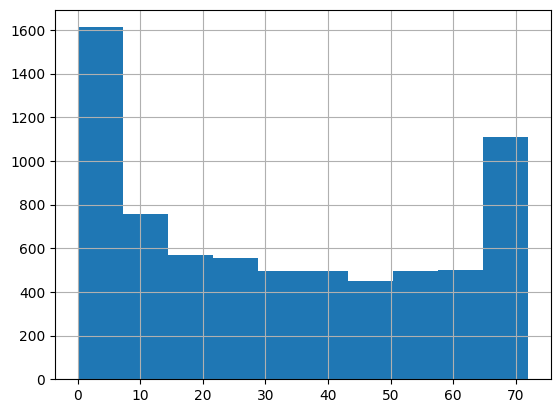

In [69]:
display(df["tenure"].describe())
df["tenure"].hist()

Tenure is number of months with the company, so 6 years as a maximum and 0 years is a a minimum. Its concentrated at the tails and uniform in the middle, which is interesting to me? I'd expect it to maybe be pareto.

In [70]:
print(df["PhoneService"].value_counts())

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


Overwhelmingly yes which is expected for a telco company, its ~10% Nos, or 682 which is decent enough examples. I had to look to make sure but it does do other services too and churn captures "leaving the company", which for lack of clarity I assume means discontinue all services.

In [71]:
print(df["MultipleLines"].value_counts())

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


I am an exact here with the phone service, I think we should drop phone service entirely as this captures that information and more.

In [72]:
((df["PhoneService"] == "No") ==  (df["MultipleLines"] == "No phone service")).mean()

np.float64(1.0)

Not inconsistent at all so we'll drop it from analysis

In [73]:
df = df.drop(columns=["PhoneService"])

In [74]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Even split among type, though this feature conceptually mixes the concept of type of internet as well as whether there is one or not as seems to be the style in this dataset (heirarchical).

In [75]:
print(df["OnlineSecurity"].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [76]:
print(df["OnlineBackup"].value_counts())

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


In [77]:
print(df["DeviceProtection"].value_counts())

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


In [78]:
print(df["TechSupport"].value_counts())

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [79]:
print(df["StreamingTV"].value_counts())

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


In [80]:
print(df["StreamingMovies"].value_counts())

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


These are the descendent features of internet service (hierarchy), they're evenly split but there maybe we can merge these in a conceptually helpful (for interpretability) way, maybe something like number of add-ons for internet or something.

In [81]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Good porportions, intuitively seems like a good predictor, since month to month valued the ability to switch.

In [82]:
print(df["PaperlessBilling"].value_counts())

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


Good porportions, I don't expect massive predictive power but lets see.

In [83]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


Good porportions.

In [84]:
print(df["MonthlyCharges"].describe())
df["MonthlyCharges"].isna().sum()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


np.int64(0)

<Axes: >

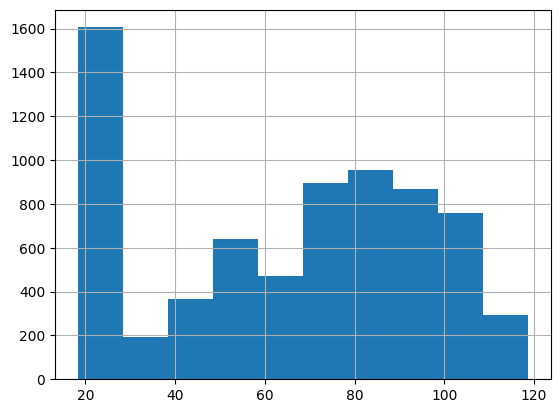

In [85]:
df["MonthlyCharges"].hist()

Seems clean no invalid data, and ranges seem appropriate

In [86]:
print(df["TotalCharges"].describe())

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object


In [87]:
# we should convert the total charges to number, NAN where not possible or blank
pd.to_numeric(df["TotalCharges"], errors='coerce').isna().sum()

np.int64(11)

11 were invalid. This is 11/ 7043 is 0.1 % of the dataset, lets look at the clean first.

In [88]:
total_charges_converted = pd.to_numeric(df["TotalCharges"], errors='coerce')

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


<Axes: >

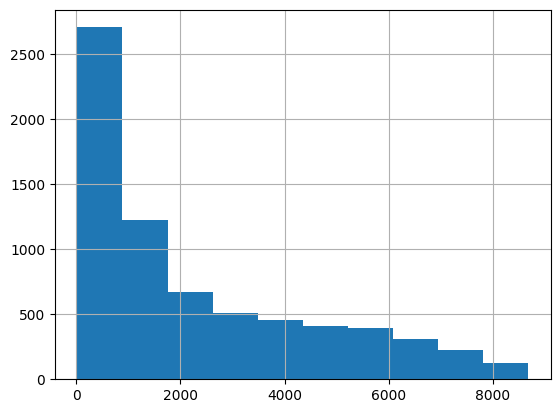

In [89]:
print(total_charges_converted.dropna(ignore_index=True).describe())
total_charges_converted.hist()

Seems clean enough though those are some big bills and a huge range. The metadata says the total amount charged to customer. I thought it was yearly but 12 * 118 is 1.4k, which misses the mark, but considering the max tenure is 72 * 118 is $8500, which makes sense with what we're seeing, so this is total over the lifetime of the customer's relationship with the telco company (suspecting monthly_charges * tenure), lets see.

In [90]:
difference = df["tenure"] * df["MonthlyCharges"] - total_charges_converted

count    7032.000000
mean       -0.153193
std        67.255326
min      -373.250000
25%       -28.700000
50%         0.000000
75%        28.650000
max       370.850000
dtype: float64


<Axes: >

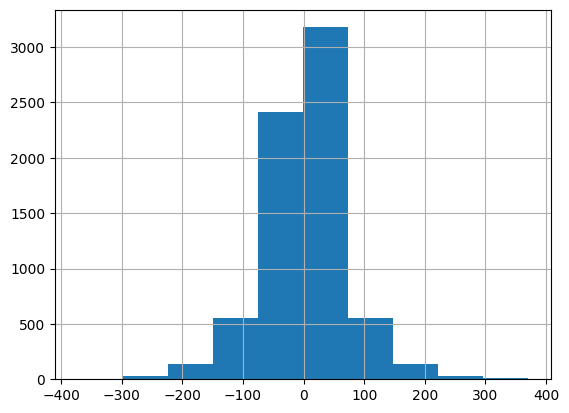

In [91]:
print(difference.describe())
difference.hist()

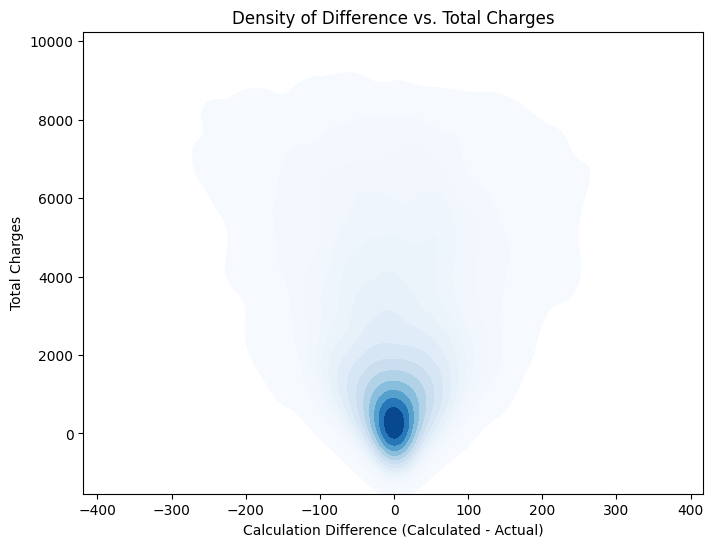

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))

# 'Blues' blends nicely with the white background, 'levels=15' makes the contours smoother
sns.kdeplot(x=difference, y=total_charges_converted, fill=True, cmap="Blues", thresh=0.01, levels=15)

plt.title("Density of Difference vs. Total Charges")
plt.xlabel("Calculation Difference (Calculated - Actual)") # Fixed the 'None' label
plt.ylabel("Total Charges")
plt.show()

So most of the data is just the monthly times the tenure, but as the projected bill gets bigger there is a higher variance on this estimate.
This can be converted into a useful feature though, like if theres variance in the estimate could indicate recent bill changes.

Now lets see whats common about the ones with NA.

In [93]:
df[total_charges_converted.isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [94]:
(df[df["tenure"] == 0].index == df[total_charges_converted.isna()].index).mean()

np.float64(1.0)

In [95]:
total_charges_converted.loc[df["tenure"] == 0] = 0

So it looks like we could replace with 0s.

In [96]:
df["TotalCharges"] = total_charges_converted

In [97]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Label looks clean enough, and relatively well balanced though not exactly, with a majority No (expected.)

### Interpretability
Given our model assumptions, we need to experiment and think about how to best engineer features that fit those assumptions.

In [98]:
df_interpertability = df.copy()
df_interpertability.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Lets start with customer ID, it's a non generalizable feature, so we drop it.

In [99]:
df_interpertability = df_interpertability.drop(columns=["customerID"])

Gender is balanced and mutually exclusive, so lets one hot encode it and make the female baseline:

In [100]:
df_interpertability["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [101]:
isMaleNotFemaleSeries = df_interpertability["gender"] == "Male"
isMaleNotFemaleSeries.mean()

np.float64(0.504756495811444)

In [102]:
df_interpertability["isMaleNotFemale"] = isMaleNotFemaleSeries.astype(int)
df_interpertability = df_interpertability.drop(columns=["gender"])

SeniorCitizen is okay balanced (16%) and mutually exclusive, so lets one hot encode it and make the non senior citizen baseline:

In [103]:
isSeniorCitizenNotRegular = df_interpertability["SeniorCitizen"] == 1
df_interpertability["isSeniorCitizenNotRegular"] = isSeniorCitizenNotRegular.astype(int)
print(isSeniorCitizenNotRegular.mean())
df_interpertability = df_interpertability.drop(columns="SeniorCitizen")

0.1621468124378816


Partner and dependents:

In [104]:
hasPartner = df_interpertability["Partner"] == "Yes"
df_interpertability["hasPartner"] = hasPartner.astype(int)
print(hasPartner.mean())
df_interpertability = df_interpertability.drop(columns="Partner")

0.4830327985233565


In [105]:
hasDependents = df_interpertability["Dependents"] == "Yes"
df_interpertability["hasDependents"] = hasDependents.astype(int)
print(hasDependents.mean())
df_interpertability = df_interpertability.drop(columns="Dependents")

0.2995882436461735


May be some correlation between dependents and has partner:

In [106]:
hasDependents.corr(hasPartner)

np.float64(0.4526762829294647)

This is relatively high correlation here - let's combine these into a household status.

In [107]:
import numpy as np
conditions = [
    (df_interpertability["hasPartner"] == 0) & (df_interpertability["hasDependents"] == 0),
    (df_interpertability["hasPartner"] == 1) & (df_interpertability["hasDependents"] == 0),
    (df_interpertability["hasPartner"] == 0) & (df_interpertability["hasDependents"] == 1),
    (df_interpertability["hasPartner"] == 1) & (df_interpertability["hasDependents"] == 1)
]

choices = ["Single", "PartnerOnly", "DependentsOnly", "Family"]

df_interpertability["HouseholdStatus"] = np.select(conditions, choices, default="Unknown")
df_interpertability = df_interpertability.drop(columns=["hasPartner", "hasDependents"])


In [108]:
df_interpertability["PartnerOnlyNotSingle"] = (df_interpertability["HouseholdStatus"] == "PartnerOnly").astype(int)
df_interpertability["DependentsOnlyNotSingle"] = (df_interpertability["HouseholdStatus"] == "DependentsOnly").astype(int)
df_interpertability["FamilyNotSingle"] = (df_interpertability["HouseholdStatus"] == "Family").astype(int)

df_interpertability = df_interpertability.drop(columns=["HouseholdStatus"])

Tenure is fine as is I suspect.

Multiple lines we have a clean mutually exclusive categorical. The most common is 1 line so that will be the reference class.

In [109]:
df_interpertability["NoPhoneServiceNotOneLine"] = (df_interpertability["MultipleLines"] == "No phone service").astype(int)
df_interpertability["MultipleLinesNotOneLine"] = (df_interpertability["MultipleLines"] == "Yes").astype(int)

df_interpertability = df_interpertability.drop(columns=["MultipleLines"])

In [110]:
df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["PartnerOnlyNotSingle"]), df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["DependentsOnlyNotSingle"]), df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["FamilyNotSingle"])

(np.float64(0.16057405360933358),
 np.float64(-0.06425324545207602),
 np.float64(0.00679197679232229))

Suspected correlation between multiple lines and house hold status but its pretty small.

Now we get into an interesting set of features, along with internet service, we have addons features with a category of no internet service. There will be severe multi collinearity if we take a simple approach (like simply one hot encoding each add on and internet service generally), which would bring unreliable inferences (inflating standard errors due to small determinants (or inverted small eigenvalues) used in calculating the standard errors.)

So we are going to create mutually exclusive classes with no overlap and leave the no internet service as a reference class - lets see how much data we have for each possible combination and number of add ons (as I doubt we will have every possible combination).

In [111]:
counts = (df_interpertability["OnlineSecurity"] == "Yes").astype(int) + (df_interpertability["OnlineBackup"] == "Yes") + (df_interpertability["DeviceProtection"] == "Yes") + (df_interpertability["TechSupport"] == "Yes") + (df_interpertability["StreamingMovies"] == "Yes") + (df_interpertability["StreamingTV"] == "Yes")

df_interpertability["InternetAddOnCount"] = counts

In [112]:
df_interpertability["InternetServices"] = "HasInternet" + df_interpertability["InternetService"] + "With" + df_interpertability["InternetAddOnCount"].astype(str) + "ExtraServices"
df_interpertability["InternetServices"].value_counts()

InternetServices
HasInternetNoWith0ExtraServices             1526
HasInternetFiber opticWith3ExtraServices     643
HasInternetFiber opticWith2ExtraServices     579
HasInternetFiber opticWith1ExtraServices     551
HasInternetFiber opticWith4ExtraServices     493
HasInternetDSLWith3ExtraServices             475
HasInternetDSLWith2ExtraServices             454
HasInternetDSLWith1ExtraServices             415
HasInternetFiber opticWith0ExtraServices     399
HasInternetDSLWith4ExtraServices             359
HasInternetDSLWith0ExtraServices             294
HasInternetFiber opticWith5ExtraServices     290
HasInternetDSLWith5ExtraServices             281
HasInternetDSLWith6ExtraServices             143
HasInternetFiber opticWith6ExtraServices     141
Name: count, dtype: int64

In [113]:
df_interpertability = pd.concat([df_interpertability, pd.get_dummies(df_interpertability["InternetServices"]).astype(int).drop(columns="HasInternetNoWith0ExtraServices")], axis=1)
df_interpertability = df_interpertability.drop(columns=["InternetAddOnCount", "InternetServices", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"])

So we combined it counts look good (>50 for each category)

The following are categorical and no overlap standard pick reference class (usually largest) and one hot encode rest.

In [114]:
df_interpertability["Contract_Two_Year_Not_Month_To_Month"] = (df_interpertability["Contract"] == "Two year").astype(int)
df_interpertability["Contract_One_Year_Not_Month_To_Month"] = (df_interpertability["Contract"] == "One year").astype(int)

In [115]:
df_interpertability = df_interpertability.drop(columns=["Contract"])

In [116]:
df_interpertability["NoPaperlessBilling"] = (df_interpertability["PaperlessBilling"] == "No").astype(int)
df_interpertability = df_interpertability.drop(columns=["PaperlessBilling"])

In [117]:
df_interpertability["MailedCheckNotECheck"] = (df_interpertability["PaymentMethod"] == "Mailed check").astype(int)
df_interpertability["AutoBankTransferNotECheck"] = (df_interpertability["PaymentMethod"] == "Bank transfer (automatic)").astype(int)
df_interpertability["AutoCreditCardNotECheck"] = (df_interpertability["PaymentMethod"] == "Credit card (automatic)").astype(int)

In [118]:
df_interpertability = df_interpertability.drop(columns=["PaymentMethod"])

Already processed monthly and total charges, now lets look at the label.

In [119]:
df_interpertability["Churn"] = (df_interpertability["Churn"] == "Yes").astype(int)

In [120]:
df_interpertability.head()

,tenure,MonthlyCharges,TotalCharges,Churn,isMaleNotFemale,isSeniorCitizenNotRegular,PartnerOnlyNotSingle,DependentsOnlyNotSingle,FamilyNotSingle,NoPhoneServiceNotOneLine,...,HasInternetFiber opticWith3ExtraServices,HasInternetFiber opticWith4ExtraServices,HasInternetFiber opticWith5ExtraServices,HasInternetFiber opticWith6ExtraServices,Contract_Two_Year_Not_Month_To_Month,Contract_One_Year_Not_Month_To_Month,NoPaperlessBilling,MailedCheckNotECheck,AutoBankTransferNotECheck,AutoCreditCardNotECheck
0,1,29.85,29.85,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,34,56.95,1889.50,0,1,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
2,2,53.85,108.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,45,42.30,1840.75,0,1,0,0,0,0,1,...,0,0,0,0,0,1,1,0,1,0
4,2,70.70,151.65,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
df_interpertability.describe()

,tenure,MonthlyCharges,TotalCharges,Churn,isMaleNotFemale,isSeniorCitizenNotRegular,PartnerOnlyNotSingle,DependentsOnlyNotSingle,FamilyNotSingle,NoPhoneServiceNotOneLine,...,HasInternetFiber opticWith3ExtraServices,HasInternetFiber opticWith4ExtraServices,HasInternetFiber opticWith5ExtraServices,HasInternetFiber opticWith6ExtraServices,Contract_Two_Year_Not_Month_To_Month,Contract_One_Year_Not_Month_To_Month,NoPaperlessBilling,MailedCheckNotECheck,AutoBankTransferNotECheck,AutoCreditCardNotECheck
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,0.504756,0.162147,0.234701,0.051257,0.248332,0.096834,...,0.091296,0.069999,0.041176,0.020020,0.240664,0.209144,0.407781,0.228880,0.219225,0.216101
std,24.559481,30.090047,2266.794470,0.441561,0.500013,0.368612,0.423842,0.220536,0.432076,0.295752,...,0.288050,0.255163,0.198710,0.140078,0.427517,0.406726,0.491457,0.420141,0.413751,0.411613
min,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


We have ourselves a good looking dataset to perform inference on.

In [122]:
import statsmodels.api as sm

y = df_interpertability["Churn"]
x = df_interpertability.drop(columns=["Churn"])
x = sm.add_constant(x)

model = sm.Logit(y, x).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.415155
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7012
Method:                           MLE   Df Model:                           30
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.2825
Time:                        14:51:43   Log-Likelihood:                -2923.9
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -2.1185      0.304     -6.977      0.000      -2.714      -1.523
tenure                                      -0.0551      0.007     -8.017      0.000      -0.069      -0.042
MonthlyCharges                               0.0757      0.012      6.096      0.000       0.051       0.100
TotalCharges                                 0.0003   8.09e-05      3.239      0.001       0.000       0.000
isMaleNotFemale                             -0.0220      0.065     -0.339      0.734      -0.149       0.105
isSeniorCitizenNotRegular                    0.2322      0.084      2.753      0.006       0.067       0.397
PartnerOnlyNotSingle                        -0.0028      0.086     -0.033      0.974      -0.171       0.165
DependentsOnlyNotSingle                     -0.2136      0.154     -1.382      0.167      -0.516       0.089
FamilyNotSingle                             -0.1383      0.094     -1.475      0.140      -0.322       0.046
NoPhoneServiceNotOneLine                     2.1779      0.272      8.014      0.000       1.645       2.711
MultipleLinesNotOneLine                     -0.1091      0.102     -1.074      0.283      -0.308       0.090
HasInternetDSLWith0ExtraServices            -1.0865      0.345     -3.146      0.002      -1.763      -0.410
HasInternetDSLWith1ExtraServices            -1.7044      0.413     -4.131      0.000      -2.513      -0.896
HasInternetDSLWith2ExtraServices            -2.4094      0.498     -4.841      0.000      -3.385      -1.434
HasInternetDSLWith3ExtraServices            -3.1291      0.594     -5.271      0.000      -4.293      -1.966
HasInternetDSLWith4ExtraServices            -3.4140      0.686     -4.979      0.000      -4.758      -2.070
HasInternetDSLWith5ExtraServices            -4.0464      0.786     -5.150      0.000      -5.586      -2.506
HasInternetDSLWith6ExtraServices            -5.0414      1.091     -4.623      0.000      -7.179      -2.904
HasInternetFiber opticWith0ExtraServices    -2.2420      0.630     -3.559      0.000      -3.477      -1.007
HasInternetFiber opticWith1ExtraServices    -2.7968      0.716     -3.908      0.000      -4.199      -1.394
HasInternetFiber opticWith2ExtraServices    -3.5077      0.815     -4.302      0.000      -5.106      -1.910
HasInternetFiber opticWith3ExtraServices    -4.0533      0.900     -4.505      0.000      -5.817      -2.290
HasInternetFiber opticWith4ExtraServices    -4.3618      0.981     -4.445      0.000      -6.285      -2.438
HasInternetFiber opticWith5ExtraServices    -5.0338      1.058     -4.757      0.000      -7.108      -2.960
HasInternetFiber opticWith6ExtraServices    -5.6718      1.161     -4.887      0.000      -7.946      -3.397
Contract_Two_Year_Not_Month_To_Month        -1.4486      0.181     -8.004      0.000      -1.803      -1.094
Contract_One_Year_Not_Month_To_Month        -0.6960      0.108     -6.438      0

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

def redundancy_check(x):
    print("Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.\n")
    vif_data = pd.DataFrame()
    vif_data["Feature"] = x.columns
    vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
    vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)
    print("--- Top 10 Variance Inflation Factors ---")
    print(vif_data.head(10))
redundancy_check(x)

Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.

--- Top 10 Variance Inflation Factors ---
                                     Feature         VIF
2                             MonthlyCharges  140.279774
21  HasInternetFiber opticWith3ExtraServices   67.159855
22  HasInternetFiber opticWith4ExtraServices   63.263808
20  HasInternetFiber opticWith2ExtraServices   50.048470
23  HasInternetFiber opticWith5ExtraServices   45.002897
19  HasInternetFiber opticWith1ExtraServices   36.939069
24  HasInternetFiber opticWith6ExtraServices   26.202575
16          HasInternetDSLWith5ExtraServices   21.573855
18  HasInternetFiber opticWith0ExtraServices   21.193467
15          HasInternetDSLWith4ExtraServices   20.896046


Looks like Monthly Charges is redundant information given the services, which makes sense all things considered. Let's drop it and total charges as we want to see what features effect the output.

In [124]:
x_no_charges = x.drop(columns=["MonthlyCharges", "TotalCharges"])
redundancy_check(x_no_charges)

Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.

--- Top 10 Variance Inflation Factors ---
                                     Feature       VIF
1                                     tenure  2.757418
23      Contract_Two_Year_Not_Month_To_Month  2.683077
19  HasInternetFiber opticWith3ExtraServices  1.716629
26                      MailedCheckNotECheck  1.672006
18  HasInternetFiber opticWith2ExtraServices  1.666269
17  HasInternetFiber opticWith1ExtraServices  1.644494
24      Contract_One_Year_Not_Month_To_Month  1.640606
20  HasInternetFiber opticWith4ExtraServices  1.554252
28                   AutoCreditCardNotECheck  1.511991
27                 AutoBankTransferNotECheck  1.501395


In [125]:
model = sm.Logit(y, x_no_charges).fit()
model.summary()


Optimization terminated successfully.
         Current function value: 0.419136
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7014
Method:                           MLE   Df Model:                           28
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.2756
Time:                        14:51:44   Log-Likelihood:                -2952.0
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -0.7069      0.137     -5.174      0.000      -0.975      -0.439
tenure                                      -0.0357      0.002    -15.139      0.000      -0.040      -0.031
isMaleNotFemale                             -0.0156      0.065     -0.242      0.809      -0.142       0.111
isSeniorCitizenNotRegular                    0.2550      0.084      3.032      0.002       0.090       0.420
PartnerOnlyNotSingle                        -0.0044      0.085     -0.052      0.959      -0.172       0.163
DependentsOnlyNotSingle                     -0.2299      0.154     -1.494      0.135      -0.532       0.072
FamilyNotSingle                             -0.1599      0.093     -1.713      0.087      -0.343       0.023
NoPhoneServiceNotOneLine                     0.6122      0.127      4.826      0.000       0.364       0.861
MultipleLinesNotOneLine                      0.3327      0.078      4.265      0.000       0.180       0.486
HasInternetDSLWith0ExtraServices             0.8857      0.167      5.298      0.000       0.558       1.213
HasInternetDSLWith1ExtraServices             0.7213      0.160      4.514      0.000       0.408       1.034
HasInternetDSLWith2ExtraServices             0.5082      0.171      2.970      0.003       0.173       0.844
HasInternetDSLWith3ExtraServices             0.3750      0.190      1.971      0.049       0.002       0.748
HasInternetDSLWith4ExtraServices             0.6155      0.232      2.650      0.008       0.160       1.071
HasInternetDSLWith5ExtraServices             0.5467      0.308      1.777      0.076      -0.056       1.150
HasInternetDSLWith6ExtraServices             0.1772      0.738      0.240      0.810      -1.269       1.624
HasInternetFiber opticWith0ExtraServices     1.6335      0.159     10.285      0.000       1.322       1.945
HasInternetFiber opticWith1ExtraServices     1.6579      0.151     11.014      0.000       1.363       1.953
HasInternetFiber opticWith2ExtraServices     1.6217      0.152     10.645      0.000       1.323       1.920
HasInternetFiber opticWith3ExtraServices     1.6912      0.155     10.881      0.000       1.387       1.996
HasInternetFiber opticWith4ExtraServices     2.0131      0.172     11.738      0.000       1.677       2.349
HasInternetFiber opticWith5ExtraServices     1.9058      0.216      8.810      0.000       1.482       2.330
HasInternetFiber opticWith6ExtraServices     1.8722      0.348      5.374      0.000       1.189       2.555
Contract_Two_Year_Not_Month_To_Month        -1.4574      0.179     -8.138      0.000      -1.808      -1.106
Contract_One_Year_Not_Month_To_Month        -0.6889      0.107     -6.425      0.000      -0.899      -0.479
NoPaperlessBilling                          -0.3839      0.074     -5.210      0.000      -0.528      -0.239
MailedCheckNotECheck                        -0.4317      0.095     -4.565      0

So we will now do average marginal effects, lets check continous for roughly linear log odds.

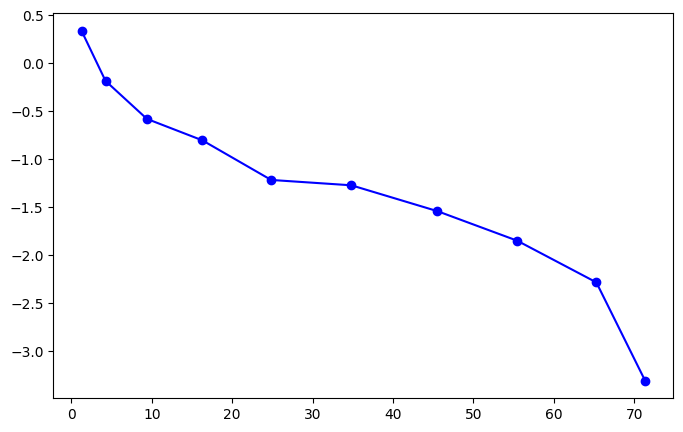

In [126]:
plot_binned_log_odds_with_label(x_no_charges["tenure"].to_numpy(), y.to_numpy())

Looks pretty good, though drop off from linear at edges, we'll keep it.

In [127]:
ame = model.get_margeff(at="overall", method="dydx")
print(ame.summary())

        Logit Marginal Effects       
Dep. Variable:                  Churn
Method:                          dydx
At:                           overall
                                              dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
tenure                                      -0.0049      0.000    -16.270      0.000      -0.005      -0.004
isMaleNotFemale                             -0.0021      0.009     -0.242      0.809      -0.019       0.015
isSeniorCitizenNotRegular                    0.0350      0.011      3.041      0.002       0.012       0.058
PartnerOnlyNotSingle                        -0.0006      0.012     -0.052      0.959      -0.024       0.022
DependentsOnlyNotSingle                     -0.0315      0.021     -1.496      0.135      -0.073       0.010
FamilyNotSingle                             -0.0219      0.013     -1.714      0.087 

So after all the hard lets see what we found (I am ignoring high p-values since they fail to have significant association with our label (0.05 cut off)).
0. Holding everything else constant, on average every month of tenure that a customer is with the company is associated with an half percent point decrease in their churn probability.
1. Holding everything else constant, on average being a senior citizen is associated with a 3.5 percentage point higher probability of churn.
2. Holding everything else constant, on average not having phone service from a baseline of one line is associated with a 8.4 percentage point increase in churn probability and having multiple lines a 4.5 percentage point increase. 
3. Holding everyting else constant, on average having DSL internet from a baseline of no internet is associated with a 5-12 percentage point increase in churn probability depending on how many extra services, with more services tending to be on the lower end of the increase.
4. Holding everyting else constant, on average having Fiber Optic internet from a baseline of no internet is associated with a 22-26 percentage point in churn probability increase depending on how many extra services, with more services tending to be on the higher end of the increase.
5. Holding everything else constant, on average having a two year contract over a baseline of month to month leads to a 20 percentage point decrease in churn probability, and a one year has a 10% percentage point decrease association.
6. Holding everything else constant, on average not having paperless billing is associated with a 5 percentage point decrease in churn probability.
7. Holding everything else constant, on average paying with mailed checks not Echecks is associated with a 6 percentage point decrease in churn probability.
8. Holding everything else constant, on average haivng automatic bank tranfers not Echecks is associated with a 5 percentage point decrease in churn probability.
9. Holding everything else constant, on average haivng automatic credit card charges not Echecks is associated with a 6.4 percentage point decrease in churn probability.

This is where these discovered associations could be used to estimate ROI on business decisions, for example helping price the contracts knowing the associated churn rate reduction on average or a discount if they go with auto pay.

### Inference Performance
Now we explore how to maximize our generalization performance on this problem. Let's train an unregularized logistic model on raw features as a baseline - see validation performance and adjust bias and variance to find our optimal generalization performance.
Lets have a hold out set of 10%, then since training is generally cheaply k-fold validation scores to compare all our models.

In [128]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
df_inference = df.drop(columns=["customerID"])
df_inference["Churn"] = (df_inference["Churn"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["gender"]).astype(int)], axis=1)
df_inference = df_inference.drop(columns=["gender"])
df_inference["Partner"] = (df_inference["Partner"] == "Yes").astype(int)
df_inference["Dependents"] = (df_inference["Dependents"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["MultipleLines"], prefix="MultipleLines").astype(int)], axis=1)
df_inference = df_inference.drop(columns="MultipleLines")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["InternetService"], prefix="InternetService").astype(int)], axis=1)
df_inference = df_inference.drop(columns="InternetService")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["OnlineSecurity"], prefix="OnlineSecurity").astype(int)], axis=1)
df_inference = df_inference.drop(columns="OnlineSecurity")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["OnlineBackup"], prefix="OnlineBackup").astype(int)], axis=1)
df_inference = df_inference.drop(columns="OnlineBackup")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["DeviceProtection"], prefix="DeviceProtection").astype(int)], axis=1)
df_inference = df_inference.drop(columns="DeviceProtection")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["TechSupport"], prefix="TechSupport").astype(int)], axis=1)
df_inference = df_inference.drop(columns="TechSupport")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["StreamingTV"], prefix="StreamingTV").astype(int)], axis=1)
df_inference = df_inference.drop(columns="StreamingTV")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["StreamingMovies"], prefix="StreamingMovies").astype(int)], axis=1)
df_inference = df_inference.drop(columns="StreamingMovies")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["Contract"], prefix="Contract").astype(int)], axis=1)
df_inference = df_inference.drop(columns="Contract")
df_inference["PaperlessBilling"] = (df_inference["PaperlessBilling"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["PaymentMethod"], prefix="PaymentMethod").astype(int)], axis=1)
df_inference = df_inference.drop(columns="PaymentMethod")

In [130]:
from sklearn.model_selection import train_test_split

x = df_inference.drop(columns=["Churn"])
y = df_inference["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.1)
x_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Female,Male,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
678,0,0,0,3,0,107.95,313.60,0,1,0,...,0,0,1,1,0,0,0,0,0,1
231,0,0,0,50,1,93.50,4747.50,0,1,1,...,0,0,1,1,0,0,0,1,0,0
847,0,1,1,12,0,33.15,444.75,1,0,0,...,1,0,0,0,1,0,0,1,0,0
4500,0,1,1,61,0,103.90,6449.15,0,1,1,...,0,0,1,0,1,0,0,1,0,0
1326,0,1,1,43,1,51.25,2151.60,1,0,0,...,1,0,0,0,1,0,1,0,0,0


In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)

cross_validate(model, x_train, y_train, cv=cv_strategy, scoring=["accuracy", "average_precision", "roc_auc", "f1"], return_train_score=True)

{'fit_time': array([0.23165298, 0.63867068, 0.26133275, 0.68855262, 0.61239076]),
 'score_time': array([0.00504541, 0.00307155, 0.00316882, 0.00634193, 0.00324273]),
 'test_accuracy': array([0.80362776, 0.80914826, 0.79416404, 0.79242305, 0.81610103]),
 'train_accuracy': array([0.80394477, 0.80236686, 0.80571992, 0.80753303, 0.80220864]),
 'test_average_precision': array([0.64518277, 0.66396075, 0.62758173, 0.64060187, 0.67797847]),
 'train_average_precision': array([0.66418111, 0.65620327, 0.66277727, 0.66087323, 0.65177982]),
 'test_roc_auc': array([0.84448926, 0.8576082 , 0.82449235, 0.83552632, 0.85350174]),
 'train_roc_auc': array([0.84665738, 0.8436537 , 0.85210718, 0.84928339, 0.84478893]),
 'test_f1': array([0.59380098, 0.61341853, 0.59282371, 0.56093489, 0.61359867]),
 'train_f1': array([0.5982215 , 0.59268293, 0.60266236, 0.60740145, 0.5924421 ])}

In [132]:
y_train.value_counts(normalize=True)

Churn
0    0.734617
1    0.265383
Name: proportion, dtype: float64

Accuracy is slightly better than baseline guessing the major class (6% higher accuracy). And theres only a small gap between them for accuracy and other stats are similar gaps, lets start by basis expansion to give more flexbility to the model (higher variance).

In [133]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, StandardScaler
from sklearn.feature_selection import VarianceThreshold

tenure_data = x_train[["tenure"]]

spline_maker = SplineTransformer(n_knots=3, degree=3, extrapolation='linear', include_bias=False).set_output(transform="pandas")

spline_data = spline_maker.fit_transform(tenure_data)

scaler = StandardScaler().set_output(transform="pandas")

x_train_basis_expansion = pd.concat([x_train.drop(columns=["tenure"]), spline_data], axis=1)

polynomial_feature_maker = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True).set_output(transform="pandas")
x_train_basis_expansion =polynomial_feature_maker.fit_transform(x_train_basis_expansion)
variance_filter = VarianceThreshold(threshold=0.0).set_output(transform="pandas")
x_train_basis_expansion = variance_filter.fit_transform(x_train_basis_expansion)
x_train_basis_expansion =  scaler.fit_transform(x_train_basis_expansion)
x_train_basis_expansion.head()

,SeniorCitizen,Partner,Dependents,PaperlessBilling,MonthlyCharges,TotalCharges,Female,Male,MultipleLines_No,MultipleLines_No phone service,...,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_1,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_2,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_3,PaymentMethod_Mailed check tenure_sp_1 tenure_sp_2,PaymentMethod_Mailed check tenure_sp_1 tenure_sp_3,PaymentMethod_Mailed check tenure_sp_2 tenure_sp_3,tenure_sp_0 tenure_sp_1 tenure_sp_2,tenure_sp_0 tenure_sp_1 tenure_sp_3,tenure_sp_0 tenure_sp_2 tenure_sp_3,tenure_sp_1 tenure_sp_2 tenure_sp_3
678,-0.439486,-0.969233,-0.657754,-1.201779,1.432619,-0.870309,-0.988080,0.988080,-0.960089,-0.327813,...,2.989609,2.934787,-0.144024,1.652781,-0.303167,-0.281755,1.619707,-0.512050,-0.563085,-0.780549
231,-0.439486,-0.969233,-0.657754,0.832100,0.952266,1.089646,-0.988080,0.988080,1.041570,-0.327813,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,0.548831
847,-0.439486,1.031744,1.520326,-1.201779,-1.053912,-0.812336,1.012064,-1.012064,-0.960089,3.050523,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,0.625912,1.868582,1.046906,-0.575651
4500,-0.439486,1.031744,1.520326,-1.201779,1.297987,1.841841,-0.988080,0.988080,1.041570,-0.327813,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,-0.627621
1326,-0.439486,1.031744,1.520326,0.832100,-0.452225,-0.057842,1.012064,-1.012064,-0.960089,3.050523,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,1.643566


In [134]:
model = LogisticRegression(solver="liblinear", penalty='l1', C=0.0225)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)
cross_validate(model, x_train_basis_expansion, y_train, cv=cv_strategy, scoring=["accuracy", "average_precision", "roc_auc", "f1"], return_train_score=True)

{'fit_time': array([1.38634276, 1.1951611 , 1.20435905, 1.15667963, 1.14424324]),
 'score_time': array([0.04483891, 0.03641152, 0.03259754, 0.03677392, 0.04267621]),
 'test_accuracy': array([0.80283912, 0.79337539, 0.80362776, 0.81136543, 0.79558011]),
 'train_accuracy': array([0.81380671, 0.81577909, 0.81282051, 0.80871623, 0.81620982]),
 'test_average_precision': array([0.65974973, 0.67580334, 0.65311093, 0.65308514, 0.66751345]),
 'train_average_precision': array([0.69833958, 0.6950149 , 0.7025372 , 0.69838173, 0.69876087]),
 'test_roc_auc': array([0.85574258, 0.84141522, 0.83707414, 0.84819351, 0.84571441]),
 'train_roc_auc': array([0.86239762, 0.86577341, 0.86648157, 0.86328011, 0.86548501]),
 'test_f1': array([0.57627119, 0.57605178, 0.5786802 , 0.59145299, 0.55726496]),
 'train_f1': array([0.59554413, 0.6134106 , 0.60042105, 0.58967851, 0.60641892])}

So i did some tuning this was the best I could get varying regularization strength.
Honestly maybe a few points which is nice - but to go to 9k features (> number of training examples), its hardly worth it.
This tells us we're probably brushing up against the irreducible error rate (which looking through Kaggle ~81% accuracy seems to be the most anyones done).

## High scale
For a higher scale problem we will look at Avazu click through rate prediction. See [here](https://www.kaggle.com/c/avazu-ctr-prediction) for more information.

It is a Mobile Advertising dataset. The goal is binary classification: predicting whether a user will tap on a mobile ad (click = 1) or ignore it (click = 0).

In [1]:
from pathlib import Path
output_dir = Path('./.data/')
output_dir.mkdir(exist_ok=True)

!wget -P .data/ -c https://zenodo.org/records/2594012/files/Avazu.zip

--2026-07-16 14:45:37--  https://zenodo.org/records/2594012/files/Avazu.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1362361557 (1.3G) [application/octet-stream]
Saving to: ‘.data/Avazu.zip’

Avazu.zip             0%[                    ]   3.74M   608KB/s    eta 38m 43s^C


In [ ]:
import zipfile

print("Unzipping Avazu...")
with zipfile.ZipFile(".data/Avazu.zip", 'r') as zip_ref:
    zip_ref.extractall(".data/")
    
print("Unzipped successfully!")

Unzipping Avazu...
Unzipped successfully!


Some info from unzipped PDF:

train - Training set. 10 days of click-through data, ordered chronologically. Non-clicks and clicks are subsampled according to
diﬀerent strategies.


test - Test set. 1 day of ads to for testing your model predictions.

I also saw an unlabeled about same size of train - I am going to simply remove it as we're really only interested in labeled data for the sake of CTR prediction.

In [2]:
!rm -rf .data/unlabeled.csv
!rm -rf .data/Avazu.zip

In [5]:
import pandas as pd
training_df = pd.read_csv(".data/train.csv")

: 

So we can't even load it, with our standard tools.

We can use our spark cluster to sample the dataset and build our prototypical pipeline to then scale it on our cluster.

### High Scale with Spark
To scale beyond the single machine set up, spark is the standard production grade technology. Here we will spin up a spark cluster and run a job to scalably handle a dataset this size.

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Sampler") \
    .master(f"spark://spark-master:7077") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/28 15:02:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
full_dataset_path = f"./.data/*csv"
full_df = spark.read.csv(full_dataset_path, header=True, inferSchema=True)
full_df.count()

40428967

In [4]:
# 40.4 million rows
# we will sample to get 40k for local pipeline prototyping
full_df.printSchema()

root
 |-- id: decimal(20,0) (nullable = true)
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- device_ip: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



In [5]:
from pyspark.sql.functions import col

## firstly lets figure out the porportion
total_rows = full_df.count()

distribution_df = full_df.groupBy("click").count().withColumn("normalized_fraction", col("count") / total_rows)
distribution_df.show()

+-----+--------+-------------------+
|click|   count|normalized_fraction|
+-----+--------+-------------------+
|    1| 6865066|0.16980562476404604|
|    0|33563901|  0.830194375235954|
+-----+--------+-------------------+



So roughly 17% click, lets do a stratified sample preserving the natural porportion.

In [6]:
fractions = {0: 0.01, 1: 0.01}
sample_df = full_df.stat.sampleBy("click", fractions)

In [7]:
sample_df.coalesce(1).write.mode("overwrite").option("header", "true").csv("./.data/sample")

In [ ]:
spark.stop()

In [3]:
import pandas as pd
import glob
file_path = glob.glob("./.data/sample/*.csv")[0]
df_sample = pd.read_csv(file_path)

In [4]:
df_sample.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,10004995556150505911,0,14103000,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,0,23723,320,50,2716,3,47,-1,23
1,10007679073563164326,0,14103000,1005,1,85f751fd,c4e18dd6,50e219e0,1dc72b4d,2347f47a,...,1,0,23701,300,50,2714,3,35,100013,23
2,10007968754262354749,1,14103000,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,2,23729,320,50,2717,2,47,-1,23
3,10013245526214578652,0,14103000,1005,1,85f751fd,c4e18dd6,50e219e0,cf0327f9,2347f47a,...,1,2,23699,300,50,2714,3,35,-1,23
4,10020602568612203135,1,14103000,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,0,23725,320,50,2716,3,47,-1,23


In [5]:
# lets check for nas per feature
df_sample.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,4.042550e+05,404255.000000,4.042550e+05,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000,404255.000000
mean,9.223100e+18,0.169433,1.410256e+07,1004.966776,0.287645,1.014904,0.331457,18835.680288,318.933198,60.003715,2112.066243,1.431173,226.640967,53262.183528,83.496672
std,5.329455e+18,0.375134,2.968887e+02,1.094955,0.504317,0.527441,0.855203,4969.246077,21.690272,47.181443,610.725074,1.326614,350.501302,49954.017586,70.336918
min,6.825165e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.000000,20.000000,112.000000,0.000000,33.000000,-1.000000,1.000000
25%,4.603419e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.000000,50.000000,1863.000000,0.000000,35.000000,-1.000000,23.000000
50%,9.232372e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.000000,50.000000,2323.000000,2.000000,39.000000,100050.000000,61.000000
75%,1.384846e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21894.000000,320.000000,50.000000,2526.000000,3.000000,171.000000,100094.000000,108.000000
max,1.844672e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24052.000000,1024.000000,1024.000000,2758.000000,3.000000,1839.000000,100248.000000,255.000000


In [6]:
df_sample.isna().sum(axis=0)

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64

Let's do some EDA on this data.

In [7]:
df_sample["id"].is_unique

True

ID is unique, drop it

In [8]:
df_sample = df_sample.drop(columns="id")

In [9]:
df_sample["click"].value_counts(normalize=True)

click
0    0.830567
1    0.169433
Name: proportion, dtype: float64

Good to see it preserved porportions as expected. Nothing funny about it.

In [10]:
df_sample["hour"].value_counts(normalize=True)

hour
14102210    0.010859
14102209    0.010842
14102813    0.010694
14102212    0.010140
14102211    0.009605
              ...   
14102419    0.000774
14102423    0.000618
14102420    0.000542
14102421    0.000463
14102422    0.000361
Name: proportion, Length: 240, dtype: float64

Per the data description: "hour: format is YYMMDDHH, so 14091123 means 23:00 on Sept. 11, 2014 UTC."

This can be a useful feature but currently its not in an easily generalizable form. 

In [11]:
df_sample["hour"].describe()["min"], df_sample["hour"].describe()["max"]

(np.float64(14102100.0), np.float64(14103023.0))

Our sample goes from 21st to 30th it appears (10 days).
The best path is probably to do day of week + hour as categorical variables we extract.

In [12]:
# convert the format to standard date times to extract the features
datetimes = pd.to_datetime(df_sample["hour"], format="%y%m%d%H")

In [13]:
df_sample["the_hour"] = datetimes.dt.hour
df_sample["weekday"] = datetimes.dt.day_name()

df_sample[["weekday","the_hour"]].head()

,weekday,the_hour
0,Thursday,0
1,Thursday,0
2,Thursday,0
3,Thursday,0
4,Thursday,0


<Axes: >

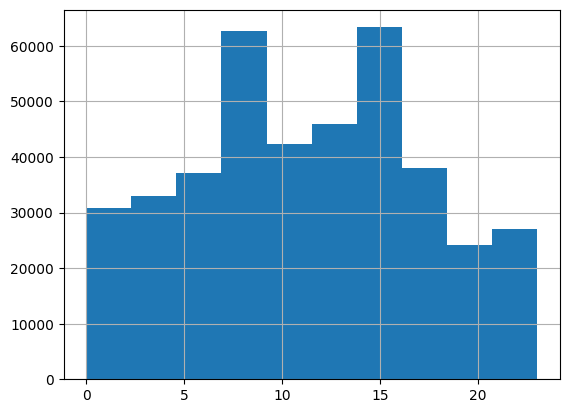

In [14]:
df_sample["the_hour"].hist()

In [15]:
all(df_sample["hour"].sort_values().index == df_sample.index)

False

In [16]:
df_sample = df_sample.sort_values(by="hour", ignore_index=True)

It doesn't look like it sorted based on timestamp, so we did that first.

Lets consider category 1.

In [17]:
df_sample["C1"].value_counts(normalize=True)

C1
1005    0.918373
1002    0.055200
1010    0.022293
1012    0.002793
1007    0.000945
1001    0.000245
1008    0.000151
Name: proportion, dtype: float64

Majority 1005 at 91%, and 1002 and 1010 at 5.5 and 2.2%, then very minor categories after the fact.
If this was for interpertability I'd consider how to divide these up more maybe ever C1 above 1% gets a category otherwise some unknown category so we still handle that at test time.

In [18]:
df_sample["banner_pos"].value_counts(normalize=True)

banner_pos
0    0.720112
1    0.278188
7    0.001022
2    0.000260
4    0.000230
5    0.000151
3    0.000037
Name: proportion, dtype: float64

Okay so it appears like really its either positioned at 0 or at 1, rest are 1% or below.

In [19]:
df_sample["site_id"].value_counts(normalize=True)

site_id
85f751fd    0.361171
1fbe01fe    0.160985
e151e245    0.065315
d9750ee7    0.023747
5b08c53b    0.022115
              ...   
ead2ee2a    0.000002
b0dab9cf    0.000002
862bb26d    0.000002
d77d8efd    0.000002
278f8f77    0.000002
Name: proportion, Length: 2161, dtype: float64

So this is across 2,000 sites, distribution drops off quickly as expected, 

In [20]:
df_sample["site_domain"].value_counts(normalize=True)

site_domain
c4e18dd6    0.374180
f3845767    0.160985
7e091613    0.082455
7687a86e    0.031515
98572c79    0.024635
              ...   
40cc1c5b    0.000002
b7e186ff    0.000002
7a117ff0    0.000002
d8686da6    0.000002
2344ad77    0.000002
Name: proportion, Length: 2196, dtype: float64

Interesting to note theres more site domains than Ids, so a particularly company may have more than one domain they want to run ads for under the same account.

In [21]:
df_sample["site_category"].value_counts(normalize=True)

site_category
50e219e0    0.409630
f028772b    0.312753
28905ebd    0.182662
3e814130    0.075116
f66779e6    0.006063
75fa27f6    0.004025
335d28a8    0.003391
76b2941d    0.002587
c0dd3be3    0.000997
70fb0e29    0.000673
72722551    0.000613
dedf689d    0.000609
0569f928    0.000445
8fd0aea4    0.000203
42a36e14    0.000082
a818d37a    0.000074
bcf865d9    0.000032
e787de0e    0.000030
9ccfa2ea    0.000007
5378d028    0.000005
da34532e    0.000002
Name: proportion, dtype: float64

In [22]:
df_sample["app_id"].value_counts(normalize=True)

app_id
ecad2386    0.638829
92f5800b    0.038221
e2fcccd2    0.028010
9c13b419    0.018726
febd1138    0.018394
              ...   
0d8ea983    0.000002
cdfdfa78    0.000002
47f1c67c    0.000002
83942c33    0.000002
13907a3a    0.000002
Name: proportion, Length: 2266, dtype: float64

In [23]:
df_sample["app_domain"].value_counts(normalize=True)

app_domain
7801e8d9    0.673362
2347f47a    0.130749
ae637522    0.046241
5c5a694b    0.028014
82e27996    0.018394
              ...   
2c1c31c6    0.000002
a09b1cc0    0.000002
2022d54e    0.000002
e51135b7    0.000002
b50610ee    0.000002
Name: proportion, Length: 156, dtype: float64

Similar to the site id vs domain here the app domain is number of companies and ids are all their apps.

In [24]:
df_sample["device_id"].value_counts(normalize=True)

device_id
a99f214a    0.823854
0f7c61dc    0.000515
c357dbff    0.000455
936e92fb    0.000331
afeffc18    0.000225
              ...   
e94c0f40    0.000002
19c175c7    0.000002
893d47a1    0.000002
995d4eb7    0.000002
00b51312    0.000002
Name: proportion, Length: 65385, dtype: float64

Device ID is 65k unique in our 400k sized dataset we will check if it trackign is disabled or not (via device_id == a99f214a) which we assume is the no tracking ID due to the distribution (82%, no thing even a tenth of a percent on any other value).

In [25]:
df_sample["device_tracking_enabled"] = (df_sample["device_id"] == "a99f214a").astype(int)

In [26]:
df_sample["device_tracking_enabled"].value_counts(normalize=True)

device_tracking_enabled
1    0.823854
0    0.176146
Name: proportion, dtype: float64

In [27]:
df_sample = df_sample.drop(columns=["device_id"])

In [28]:
df_sample["device_ip"].value_counts(normalize=True)

device_ip
6b9769f2    0.005125
431b3174    0.003339
2f323f36    0.002236
930ec31d    0.002202
6394f6f6    0.002182
              ...   
d9ffca0d    0.000002
fa84956c    0.000002
0f3b3fbb    0.000002
4ce9b0ab    0.000002
e16d269a    0.000002
Name: proportion, Length: 263020, dtype: float64

Device IP looks useless, if it wasn't anonymized we could get some geo out of it but as it is will drop it.

In [29]:
df_sample = df_sample.drop(columns=["device_ip"])

In [30]:
df_sample["device_model"].value_counts(normalize=True)

device_model
8a4875bd    0.060833
1f0bc64f    0.035193
d787e91b    0.035141
76dc4769    0.018862
be6db1d7    0.018523
              ...   
54667181    0.000002
80cde8be    0.000002
a393dd83    0.000002
19d1a8c9    0.000002
f57802a7    0.000002
Name: proportion, Length: 4388, dtype: float64

Some make it past 5% so i think a filter of above 1% would do well for us here and keep rare devices in a bucket.

In [31]:
df_sample["device_type"].value_counts(normalize=True)

device_type
1    0.922507
0    0.055200
4    0.019067
5    0.003226
Name: proportion, dtype: float64

Good porportion low cardinality feature.

In [32]:
df_sample["device_conn_type"].value_counts(normalize=True)

device_conn_type
0    0.862876
2    0.082146
3    0.053862
5    0.001116
Name: proportion, dtype: float64

Same as previous low cardinality.

In [33]:
df_sample["C14"].value_counts(normalize=True)

C14
4687     0.023770
21611    0.022473
21191    0.018827
21189    0.018763
19771    0.018013
           ...   
23363    0.000002
21920    0.000002
22852    0.000002
23606    0.000002
18433    0.000002
Name: proportion, Length: 2079, dtype: float64

2k features but some above 1%, well encode those above 1% and rest bucket.

In [34]:
df_sample["C15"].value_counts(normalize=True)

C15
320     0.933112
300     0.057303
216     0.007391
728     0.001920
120     0.000087
1024    0.000067
480     0.000067
768     0.000054
Name: proportion, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [35]:
df_sample["C16"].value_counts(normalize=True)

C16
50      0.943726
250     0.044183
36      0.007391
480     0.002506
90      0.001920
20      0.000087
768     0.000067
320     0.000067
1024    0.000054
Name: proportion, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [36]:
df_sample["C17"].value_counts(normalize=True)

C17
1722    0.111724
2424    0.037590
2227    0.036215
1800    0.029489
423     0.023770
          ...   
2719    0.000002
2582    0.000002
2375    0.000002
2568    0.000002
2758    0.000002
Name: proportion, Length: 413, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [37]:
df_sample["C18"].value_counts(normalize=True)

C18
0    0.419656
3    0.337663
2    0.175503
1    0.067178
Name: proportion, dtype: float64

Seems like a good feature above.

In [38]:
df_sample["C19"].value_counts(normalize=True)

C19
35      0.301681
39      0.218661
167     0.077555
161     0.038958
47      0.035760
          ...   
1583    0.000087
683     0.000020
1447    0.000010
1195    0.000007
545     0.000005
Name: proportion, Length: 66, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [39]:
df_sample["C20"].value_counts(normalize=True)

C20
-1         0.467972
 100084    0.060165
 100148    0.044405
 100111    0.042624
 100077    0.039270
             ...   
 100137    0.000010
 100175    0.000007
 100100    0.000002
 100078    0.000002
 100186    0.000002
Name: proportion, Length: 160, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [40]:
df_sample["C21"].value_counts(normalize=True).head()

C21
23     0.219913
221    0.125535
79     0.114272
48     0.053187
71     0.051876
Name: proportion, dtype: float64

Not too bad, though there are some really low fraction ones, well do the 1% encoding threshold.

In [41]:
df_sample["hour"]

0         14102100
1         14102100
2         14102100
3         14102100
4         14102100
            ...   
404250    14103023
404251    14103023
404252    14103023
404253    14103023
404254    14103023
Name: hour, Length: 404255, dtype: int64

Per the data description: "hour: format is YYMMDDHH, so 14091123 means 23:00 on Sept. 11, 2014 UTC.", so we will leave last day as test set and previous days as training set we'll do CV over.

In [42]:
(df_sample["hour"] // 1e2 % 100).describe()

count    404255.000000
mean         25.466587
std           2.965424
min          21.000000
25%          23.000000
50%          26.000000
75%          28.000000
max          30.000000
Name: hour, dtype: float64

In [43]:
(df_sample["hour"] // 1e2 % 100 == 30).mean()

np.float64(0.10423618755488491)

Which is about 10% of the data.

In [44]:
train_data = df_sample[df_sample["hour"] // 1e2 % 100 != 30]
test_data = df_sample[df_sample["hour"] // 1e2 % 100 == 30]

In [45]:
(train_data["hour"] // 1e2 % 100 == 30).mean(), train_data.shape, (test_data["hour"] // 1e2 % 100 == 30).mean(), test_data.shape

(np.float64(0.0), (362117, 24), np.float64(1.0), (42138, 24))

In [46]:
train_data.head()

,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,C15,C16,C17,C18,C19,C20,C21,the_hour,weekday,device_tracking_enabled
0,0,14102100,1005,0,cd58172f,b9c4ab81,f028772b,ecad2386,7801e8d9,07d7df22,...,320,50,2161,0,35,100103,157,0,Tuesday,1
1,0,14102100,1010,1,85f751fd,c4e18dd6,50e219e0,a607e6a7,7801e8d9,0f2161f8,...,320,50,2493,3,35,-1,117,0,Tuesday,0
2,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,1779deee,2347f47a,f95efa07,...,320,50,2161,0,35,100160,157,0,Tuesday,1
3,0,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,320,50,1993,2,1063,100084,33,0,Tuesday,1
4,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,320,50,1722,0,35,-1,79,0,Tuesday,1


In [47]:
train_data.tail()

,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,C15,C16,C17,C18,C19,C20,C21,the_hour,weekday,device_tracking_enabled
362112,1,14102923,1002,0,85f751fd,c4e18dd6,50e219e0,a37bf1e4,7801e8d9,07d7df22,...,320,50,1722,0,35,100084,79,23,Wednesday,0
362113,0,14102923,1005,0,85f751fd,c4e18dd6,50e219e0,92f5800b,ae637522,0f2161f8,...,320,50,2424,1,161,100191,71,23,Wednesday,1
362114,1,14102923,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,07d7df22,...,320,50,1974,2,39,-1,33,23,Wednesday,1
362115,0,14102923,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,07d7df22,...,320,50,2716,3,47,-1,23,23,Wednesday,1
362116,0,14102923,1005,0,85f751fd,c4e18dd6,50e219e0,febd1138,82e27996,0f2161f8,...,320,50,2480,3,297,100111,61,23,Wednesday,1


In [48]:
train_data = train_data.drop(columns=["hour"])
test_data = test_data.drop(columns=["hour"])

In [49]:
train_X = train_data.drop(columns=["click"])
train_Y = train_data["click"]

test_X = test_data.drop(columns=["click"])
test_Y = test_data["click"]

In [50]:
train_X.columns.to_list()

['C1',
 'banner_pos',
 'site_id',
 'site_domain',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_model',
 'device_type',
 'device_conn_type',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'the_hour',
 'weekday',
 'device_tracking_enabled']

In [53]:
## Let's cache this.
!mkdir -p .data/sample_cleaned
train_X.to_pickle(".data/sample_cleaned/train_X.pkl")
train_Y.to_pickle(".data/sample_cleaned/train_Y.pkl")
test_X.to_pickle(".data/sample_cleaned/test_X.pkl")
test_Y.to_pickle(".data/sample_cleaned/test_Y.pkl")

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    min_frequency=0.01,
    handle_unknown="infrequent_if_exist",
    sparse_output=True
)

prepocessor = ColumnTransformer(
    transformers=[
        ("cat_encoder", encoder, train_X.columns.to_list())
    ],
    remainder='drop',
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', prepocessor)
    ]
)

In [50]:
pipeline.fit_transform(train_X)[:5].toarray()

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.]], shape=(5, 217))

In [51]:
prepocessor.get_feature_names_out()[:5]

array(['cat_encoder__C1_1002', 'cat_encoder__C1_1005',
       'cat_encoder__C1_1010', 'cat_encoder__C1_infrequent_sklearn',
       'cat_encoder__banner_pos_0'], dtype=object)

So we know have a reusable pipeline trained on train that we can use for test later.

In [52]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np

cv = TimeSeriesSplit(n_splits=5)
estimator = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=500,
)
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid={
        'C': np.linspace(0.75, 1.5, 10)
    },
    cv=cv,
    scoring=["roc_auc", "neg_log_loss", "accuracy"],
    refit="neg_log_loss",
    n_jobs=2
)

grid_search.fit(pipeline.fit_transform(train_X), train_Y)

,estimator,LogisticRegre...r='liblinear')
,param_grid,"{'C': array([0.75 ..., 1.5 ])}"
,scoring,"['roc_auc', 'neg_log_loss', ...]"
,n_jobs,2
,refit,'neg_log_loss'
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [53]:
grid_search.best_score_, grid_search.best_estimator_

(np.float64(-0.42153555398568515),
 LogisticRegression(C=np.float64(0.8333333333333334), max_iter=500, penalty='l1',
                    solver='liblinear'))

In [54]:
from sklearn.metrics import get_scorer

scoring_metrics = ["roc_auc", "neg_log_loss", "accuracy", "average_precision"]

for score_name in scoring_metrics:
    scorer = get_scorer(score_name)
    print(f"{score_name}: {scorer(grid_search.best_estimator_, pipeline.transform(test_X), test_Y)}")

roc_auc: 0.6992764367466896
neg_log_loss: -0.41824024944734134
accuracy: 0.8315534671792681
average_precision: 0.3134991471139201


In [55]:
from sklearn.metrics import get_scorer

scoring_metrics = ["roc_auc", "neg_log_loss", "accuracy", "average_precision"]

for score_name in scoring_metrics:
    scorer = get_scorer(score_name)
    print(f"{score_name}: {scorer(grid_search.best_estimator_, pipeline.transform(train_X), train_Y)}")

roc_auc: 0.7006045243150218
neg_log_loss: -0.4172859126625707
accuracy: 0.8319023961868678
average_precision: 0.32197590572783796


Our CV score of 0.42 is not bad actually. 1k place in leaderboard but so many optimizations to explore.

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


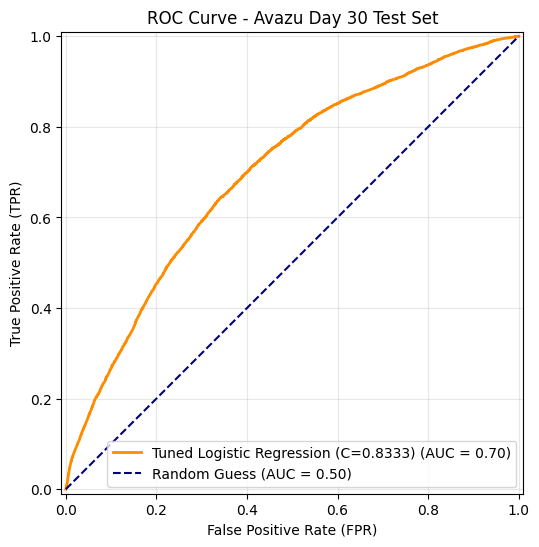

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Set up a clean, appropriately sized figure
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Automatically calculate and plot the ROC curve
# This uses the best_model and X_test_transformed from your previous step
RocCurveDisplay.from_estimator(
    estimator=grid_search.best_estimator_, 
    X=pipeline.transform(test_X), 
    y=test_Y,
    name="Tuned Logistic Regression (C=0.8333)",
    color="darkorange",
    linewidth=2,
    ax=ax
)

# 3. Add a diagonal dashed line to represent a random guess baseline
plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random Guess (AUC = 0.50)")

# 4. Add titles and labels for readability
plt.title("ROC Curve - Avazu Day 30 Test Set")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 5. Render the visualization
plt.show()

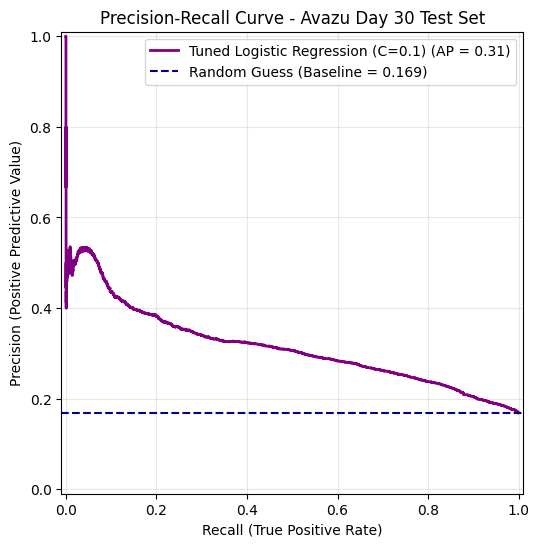

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# 1. Set up a clean figure
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Automatically calculate and plot the PR curve
PrecisionRecallDisplay.from_estimator(
    estimator=grid_search.best_estimator_, 
    X=pipeline.transform(test_X), 
    y=test_Y,
    name="Tuned Logistic Regression (C=0.1)",
    color="purple",
    linewidth=2,
    ax=ax
)

# 3. Calculate and plot the baseline (the overall click rate in the test set)
# If 16% of ads are clicked, a random model will have a Precision of 0.16 at all Recall levels
baseline = test_Y.mean() 
plt.axhline(
    y=baseline, 
    color="navy", 
    linestyle="--", 
    label=f"Random Guess (Baseline = {baseline:.3f})"
)

# 4. Add titles and labels for readability
plt.title("Precision-Recall Curve - Avazu Day 30 Test Set")
plt.xlabel("Recall (True Positive Rate)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)

# 5. Render the visualization
plt.show()

Okay thats a good baseline, lets try with interactions of higher and higher degrees, and sample so it all fits in our dataframe.

In [2]:
import pandas as pd

train_X = pd.read_pickle(".data/sample_cleaned/train_X.pkl").sample(n=100000)
train_Y = pd.read_pickle(".data/sample_cleaned/train_Y.pkl").sample(n=100000)
test_X = pd.read_pickle(".data/sample_cleaned/test_X.pkl").sample(n=10000)
test_Y = pd.read_pickle(".data/sample_cleaned/test_Y.pkl").sample(n=10000)

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np


encoder = OneHotEncoder(
    min_frequency=0.0001,
    handle_unknown="infrequent_if_exist",
    sparse_output=True
)
prepocessor = ColumnTransformer(
    transformers=[
        ("cat_encoder", encoder, train_X.columns.to_list())
    ],
    remainder='drop',
)


pipeline = Pipeline(
    steps=[
        ('preprocessor', prepocessor)
    ]
)
transformed_x = pipeline.fit_transform(train_X)
print(transformed_x.shape)

cv = TimeSeriesSplit(n_splits=5)
estimator = LogisticRegression(
    penalty="l1",
    max_iter=500,
    solver='liblinear'
)
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid={
        'C': np.linspace(0.001, 0.1, 10)
    },
    cv=cv,
    scoring=["roc_auc", "neg_log_loss", "accuracy"],
    refit="neg_log_loss",
    n_jobs=1
)

grid_search.fit(transformed_x, train_Y)

print(grid_search.best_score_, grid_search.best_estimator_)
from sklearn.metrics import get_scorer

scoring_metrics = ["roc_auc", "neg_log_loss", "accuracy", "average_precision"]

for score_name in scoring_metrics:
    scorer = get_scorer(score_name)
    print(f"{score_name}: {scorer(grid_search.best_estimator_, pipeline.transform(test_X), test_Y)}")


(100000, 3185)
-0.45364883496986896 LogisticRegression(C=np.float64(0.023000000000000003), max_iter=500,
                   penalty='l1', solver='liblinear')
roc_auc: 0.4963846974843536
neg_log_loss: -0.45977731002867706
accuracy: 0.8276
average_precision: 0.16952135856226735


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np


encoder = OneHotEncoder(
    min_frequency=0.0001,
    handle_unknown="infrequent_if_exist",
    sparse_output=True
)
prepocessor = ColumnTransformer(
    transformers=[
        ("cat_encoder", encoder, train_X.columns.to_list())
    ],
    remainder='drop',
)

polynomial_features = PolynomialFeatures(2, interaction_only=True, include_bias=True)

pipeline = Pipeline(
    steps=[
        ('preprocessor', prepocessor),
        ('polynomial_expansion', polynomial_features)
    ]
)
transformed_x = pipeline.fit_transform(train_X)
print(transformed_x.shape)

cv = TimeSeriesSplit(n_splits=5)
estimator = LogisticRegression(
    penalty="l1",
    max_iter=500,
    solver='liblinear'
)
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid={
        'C':  np.linspace(0.001, 0.1, 10)
    },
    cv=cv,
    scoring=["roc_auc", "neg_log_loss", "accuracy"],
    refit="neg_log_loss",
    n_jobs=1
)

grid_search.fit(transformed_x, train_Y)

print(grid_search.best_score_, grid_search.best_estimator_)
from sklearn.metrics import get_scorer

scoring_metrics = ["roc_auc", "neg_log_loss", "accuracy", "average_precision"]

for score_name in scoring_metrics:
    scorer = get_scorer(score_name)
    print(f"{score_name}: {scorer(grid_search.best_estimator_, pipeline.transform(test_X), test_Y)}")


(100000, 5073706)
-0.45365679698784656 LogisticRegression(C=np.float64(0.012), max_iter=500, penalty='l1',
                   solver='liblinear')
roc_auc: 0.4954633937172199
neg_log_loss: -0.45971255825431473
accuracy: 0.8276
average_precision: 0.16907264856849222


Needed to sample further else OOM.

Looks like interactions didn't help us here in lowering generalization. I suspect the high cardinality of the columns is a biggest challenge here to overcome, then we can look at how interactions improve.

Lets push spark to its limits, Logistic CV L1 super low fractional scores (small batch sizes) with this simple feature engineering.


In [18]:
from pyspark.sql import SparkSession
import os

spark = SparkSession.builder.appName("PreProcessor") \
    .master(f"spark://spark-master:7077") \
    .getOrCreate()

In [19]:
path = "./.data/*.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

In [20]:
from pyspark.sql import functions as F
df.select(F.count_distinct("id")).show()

+------------------+
|count(DISTINCT id)|
+------------------+
|          40428967|
+------------------+



In [21]:
df = df.drop("id")

In [22]:
df.show(5)

+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|click|    hour|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|app_category|device_id|device_ip|device_model|device_type|device_conn_type|  C14|C15|C16| C17|C18|C19|   C20|C21|
+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|    0|14103000|1005|         1|ec47f32a|   7e091613|     f028772b|ecad2386|  7801e8d9|    07d7df22| a99f214a| f118cfc8|    74b0fc2c|          1|               0|23536|320| 50|2695|  0| 35|100019| 51|
|    0|14103000|1005|         1|ec47f32a|   7e091613|     f028772b|ecad2386|  7801e8d9|    07d7df22| a99f214a| 273a495f|    7abbbd5c|          1|               0|23539|320| 50|2695|  0| 35|100020|

In [23]:
df = df.withColumn(
    "datetime",
    F.to_timestamp(F.col("hour").cast("string"), "yyMMddHH")
)
df = df.withColumn(
    "hour_of_the_day",
    F.hour("datetime")
)

df = df.withColumn(
    "weekday",
    F.date_format("datetime", "EEEE")
)

In [24]:
df.select(
    F.min("datetime"),
    F.max("datetime")
).show()

+-------------------+-------------------+
|      min(datetime)|      max(datetime)|
+-------------------+-------------------+
|2014-10-21 00:00:00|2014-10-30 23:00:00|
+-------------------+-------------------+



In [25]:
train_preprocessed_df = df.filter(F.substring(F.col("hour").cast("string"), 5, 2) != "30")
test_preprocessed_df = df.filter(F.substring(F.col("hour").cast("string"), 5, 2) == "30")

In [26]:
train_preprocessed_df.select(
    F.max("datetime"),
    F.min("datetime")
).show()

+-------------------+-------------------+
|      max(datetime)|      min(datetime)|
+-------------------+-------------------+
|2014-10-29 23:00:00|2014-10-21 00:00:00|
+-------------------+-------------------+



In [27]:
test_preprocessed_df.select(
    F.max("datetime"),
    F.min("datetime")
).show()

+-------------------+-------------------+
|      max(datetime)|      min(datetime)|
+-------------------+-------------------+
|2014-10-30 23:00:00|2014-10-30 00:00:00|
+-------------------+-------------------+



In [28]:
train_preprocessed_df = train_preprocessed_df.orderBy("datetime")

In [29]:
train_preprocessed_df = train_preprocessed_df.drop("hour", "datetime")
test_preprocessed_df = test_preprocessed_df.drop("hour", "datetime")

In [30]:
test_preprocessed_df.count(), train_preprocessed_df.count()

(4218938, 36210029)

In [31]:
!mkdir -p ./.data/preprocessed/train
!mkdir -p ./.data/preprocessed/test
train_preprocessed_df.coalesce(1).write.mode("overwrite").option("header", "true").parquet("./.data/preprocessed/train")
test_preprocessed_df.coalesce(1).write.mode("overwrite").option("header", "true").parquet("./.data/preprocessed/test")

In [14]:
spark.stop()

Now let's run the distributed training job for logistic regression, one hot encoding all the columns.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Repartition") \
    .master(f"spark://spark-master:7077") \
    .config("spark.kryoserializer.buffer.max", "256m") \
    .getOrCreate()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/03 17:57:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
df = spark.read.parquet("../.data/preprocessed/train")

Let's first see how to process the whole dataset at once, later we can do time series CV and whatever, but the fundamental problem is how to split the data in a way our spark can process it without OOM.

In [3]:
df.repartition(2000).write.mode("overwrite").parquet(".data/preprocessed/train_2k_partitions")


In [8]:
spark.stop()

In [ ]:
''' runner.py
from pyspark.sql import SparkSession
from pyspark.ml.feature import FeatureHasher
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

NUM_FEATURES = 8194304
MODEL_ID = "trained_1e-4_default_max_iter_8m_feats"
spark = SparkSession.builder.appName("TrainAndHyperParameterTune") \
    .master(f"spark://spark-master:7077") \
    .config("spark.kryoserializer.buffer.max", "256m") \
    .getOrCreate()
df = spark.read.parquet(".data/preprocessed/train_2k_partitions")


columns_to_exclude = {"click", "id"}
categorical_cols = [col for col in df.columns if col not in columns_to_exclude]

hasher = FeatureHasher(
    inputCols=categorical_cols,
    outputCol="features",
    numFeatures=8194304
)

lr = LogisticRegression(
    featuresCol="features", 
    labelCol="click",
    elasticNetParam=1.0,  
    regParam=0.0001

)

pipeline = Pipeline(stages=[hasher, lr])

print("Training Logistic Regression with 8.19M Hash Buckets...")
model = pipeline.fit(df)

model.save(f".data/model/{MODEL_ID}")
print("Done training")

lr_model = model.stages[-1]
training_summary = lr_model.summary

print(f"Training ROC-AUC: {training_summary.areaUnderROC}")

print(f"Final Training Log Loss: {training_summary.objectiveHistory[-1]}")


test_df = spark.read.parquet(".data/preprocessed/test") 


print("Running through test data")
test_predictions = model.transform(test_df)


evaluator_roc = BinaryClassificationEvaluator(
    labelCol="click", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)

evaluator_pr = BinaryClassificationEvaluator(
    labelCol="click", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderPR"
)

evaluator_logloss = MulticlassClassificationEvaluator(
    labelCol="click", 
    probabilityCol="probability", 
    metricName="logLoss"
)

test_roc_auc = evaluator_roc.evaluate(test_predictions)
print(f"Test ROC-AUC:  {test_roc_auc}")

test_pr_auc = evaluator_pr.evaluate(test_predictions)
print(f"Test PR-AUC:   {test_pr_auc}")

test_logloss = evaluator_logloss.evaluate(test_predictions)
print(f"Test Log Loss: {test_logloss}")
spark.stop()'''
print("Run runner.py with similar code as above - doing it in a notebook stole too much memory from my laptop.")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/06 15:09:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


If you try one hot encoding spark will break because it's not designed to be distributing metadata of that size (due to the cardinality of ip addresses and device ids).

So we used a FeatureHasher construct, instead of building a distinct map in a centralized place and then replicating that to workers, it simply hashes the values it encounters into a bucket and theres no mapping rules to broadcast because the mapping is intrinsic to the hashing which all the exectors share, so its a stateless transformation vs the stateful onehot encoding (where we need to keep rules around).

The downside is we lose visibility into the columns being used though since we're going for inference performance not too concerning. 

Also to go above 4m to 8m buckets we shifted the worker to be beefy 16gb and only 1 of them due to limitations on local compute - if we wanted multiple workers they would need to be adequately sized.

Also I had to not execute this in a notebook due to IDE and notebook overheads hogging memory :\.

In [20]:
spark.stop()

In [ ]:
# TODO: maximize bucket size, tune L1 regularization to optimize test log loss.
# TODO: host endpoint with the model

experiments:
- 4m buckets no regularization max iter == 10:
0.677 test log loss, 0.2448 test pr-auc
Training ROC-AUC: 0.85 training Log Loss: 0.3239719356500722
- 4m buckets 0.01 regularization max iter default:
Training ROC-AUC: 0.6765363194884414, Final Training Log Loss: 0.4426413632683089
- 4m buckets 0.0001 regularization max iter default:
Training ROC-AUC: 0.7845777744411819, Final Training Log Loss: 0.3950472792453413
- 4m buckets 0.00001 regularization max iter default.:
Test Log Loss: 0.4950467960996886, Test PR-AUC:   0.26959115861700794 Test ROC-AUC:  0.6758229886336671
Training ROC-AUC: 0.8490024483940819, Final Training Log Loss: 0.3441216654462702
- 4m buckets 0.00005 regularization max iter default.
Test Log Loss: 0.4224103577105429, Test PR-AUC:   0.3120140112614662 Test ROC-AUC:  0.716875884143358
Training ROC-AUC: 0.8176690343368527, Final Training Log Loss: 0.38012700087655193
- 5 million buckets, 0.00005 regularization max iter default.
Test Log Loss: 0.42431103662001574, Test PR-AUC:   0.31025449556314444 Test ROC-AUC:  0.7161560335141383
Training ROC-AUC: 0.8236965609709688, Final Training Log Loss: 0.37784224295793933
- 8 million buckets, 0.0001 regularization max iter default.
Test Log Loss: 0.40705113086711986, Test ROC-AUC:  0.731361761533501, Test PR-AUC:   0.3418749034047265
- 8 million buckets, 0.0002 regularization max iter default.
Test Log Loss: 0.40285161959604876, Test ROC-AUC:  0.735729009615018, Test PR-AUC:   0.36121762525154766                                              
Training ROC-AUC: 0.7534802118478258, Final Training Log Loss: 0.40302650500241094
- 16 million buckets, 0.0002 regularization max iter default.
   